
# Kagome fRG sanity-check pipeline

This notebook builds a **standard spinful kagome model** using the corrected `channels.py` and `frg_flow.py`, then runs two benchmark interaction points inspired by the PRL phase diagram:

- **FM benchmark:** `U=6, V=0`
- **PI benchmark:** `U=0, V=10`

Target setup:
- no flux
- van Hove filling proxy: `mu = 0`
- `Npatch = 12`

The purpose is simple:

1. verify the corrected longitudinal channel construction in a full end-to-end pipeline  
2. check whether the final leading instability looks **FM-like** for large `U`  
3. check whether it looks **PI-like** for large `V`  

If the second case still does **not** show PI-like structure, the next place to inspect is likely:
- `form_factor.py`
- `kagome_order_diagnosis.py`

---


In [1]:
import sys
from pathlib import Path
from pprint import pprint
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Make sure the uploaded modules are importable
sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver
import sys
sys.path.insert(0, "/mnt/data")


## 1. Global parameters

You can tune the flow resolution here.

Notes:
- `mu=0` matches the PRL convention for kagome VHF.
- `band_index=1` is the dispersive band crossing `mu=0` inside each 3x3 spin block.
- `Npatch=12` is intentionally small, just for a fast pipeline sanity check.
- For a more reliable final physics check, increase `Npatch`, `nfreq`, and `n_steps`.


In [3]:
# ---------- noninteracting / patching ----------
MODEL_PARAMS = dict(t=1.0, phi=0.0)   # standard kagome = phi=0
MU = 0.0
NPATCH = 24
GRID_SIZE = 320
CONTOUR_MIN_POINTS = 40

# Each spin block is 3x3 inside the full 6x6 spinful Hamiltonian
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1   # dispersive band crossing mu=0

# ---------- flow ----------
FLOW_KWARGS = dict(
    T_start=50,
    T_stop=0.5,
    n_steps=1200,
    nfreq=30,
    diagnose_every=10,
    temperature_grid="log",
    include_explicit_T_prefactor=True,
    max_relative_update=1.0,
    min_substep_fraction=0.05,
    channel_divergence_threshold=1e5,
    q_merge_tol_red=5e-2,
    q_key_decimals=10,
)

# These are no longer FRGFlowSolver __init__ kwargs.
# Keep them as a separate analysis list for later diagnostics.
DIAGNOSIS_QS = [
    np.array([0.0, 0.0]),
    np.array([0.0,  np.pi / np.sqrt(3)]),
    np.array([ np.pi / 2,  np.pi / (2 * np.sqrt(3))]),
    np.array([-np.pi / 2,  np.pi / (2 * np.sqrt(3))]),
]

## 2. Build the standard spinful kagome model and the two spin patchsets

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

Patch counts: {'up': 21, 'dn': 21}
mu used for contour (up/dn): 0.0 0.0
gauge method (up/dn): manual_exact_M_hex_parallel_transport_21_dropDupM_gaugeFixed manual_exact_M_hex_parallel_transport_21_dropDupM_gaugeFixed
gauge loop phase (up/dn): -1.2246467991473532e-16 -1.2246467991473532e-16

===== exact M6 anchors in centered 1BZ =====
M0: k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ]
M1: k=[ 0.       -1.813799] | k_can=[0.       1.813799]
M2: k=[ 1.570796 -0.9069  ] | k_can=[1.570796 2.720699]
M3: k=[1.570796 0.9069  ] | k_can=[1.570796 0.9069  ]
M4: k=[0.       1.813799] | k_can=[0.       1.813799]
M5: k=[-1.570796  0.9069  ] | k_can=[1.570796 2.720699]

===== kept indices in full loop =====
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 19, 21, 22, 23]

===== up exact-M21 patches =====
id= 0 | k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ] | E=1.0947644253e-47 | |vF|=7.747454e-16 | w=[0. 1. 0.]
id= 1 | k=[-1.178097 -1.133625] | k_can=[1.963495 4.307773] | E=1.52

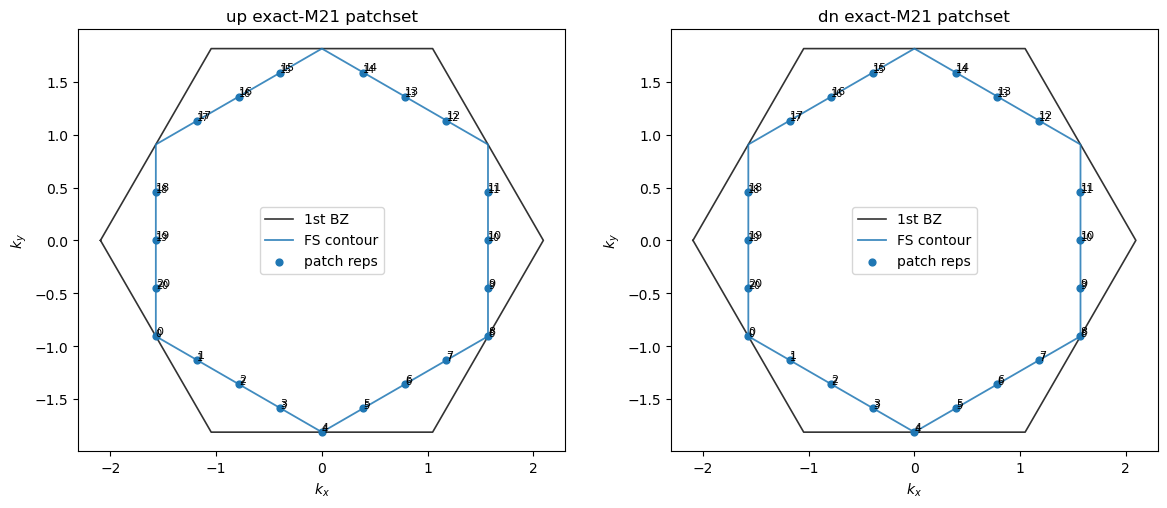

In [5]:
# ============================================================
# Manual exact-M patchsets on standard centered 1BZ hexagon
# with:
#   (1) optional duplicated-M removal modulo G
#   (2) explicit gauge fixing of Bloch states
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from patching import PatchPoint, PatchSet, plot_patchset

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

# ------------------------------------------------------------
# basic helpers
# ------------------------------------------------------------
def _sector_eig(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    u = u / np.linalg.norm(u)
    return float(evals[band_index]), u

def _orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex))**2
    return w / np.sum(w)

def _cart_to_red(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    return np.linalg.solve(B, np.asarray(k, dtype=float))

def _finite_diff_velocity(model, k_cart, orbital_slice, band_index, h=1e-6):
    kx, ky = float(k_cart[0]), float(k_cart[1])

    def band_energy(x, y):
        H = np.asarray(model.Hk(x, y), dtype=complex)
        Hs = H[orbital_slice, orbital_slice]
        evals, _ = np.linalg.eigh(Hs)
        return float(evals[band_index])

    vx = (band_energy(kx + h, ky) - band_energy(kx - h, ky)) / (2*h)
    vy = (band_energy(kx, ky + h) - band_energy(kx, ky - h)) / (2*h)
    return np.array([vx, vy], dtype=float)

# ------------------------------------------------------------
# reciprocal helpers
# ------------------------------------------------------------
def _wrap_unit_interval(x, tol=1e-12):
    x = np.asarray(x, dtype=float)
    x = x - np.floor(x)
    x[np.isclose(x, 1.0, atol=tol)] = 0.0
    x[np.isclose(x, 0.0, atol=tol)] = 0.0
    return x

def _canonicalize_k_mod_G(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    uv = np.linalg.solve(B, np.asarray(k, dtype=float))
    uv = _wrap_unit_interval(uv)
    k_can = B @ uv
    k_can[np.isclose(k_can, 0.0, atol=1e-12)] = 0.0
    return k_can

# ------------------------------------------------------------
# 1BZ geometry
# ------------------------------------------------------------
def hex_bz_vertices(model):
    """
    Standard centered 1BZ hexagon vertices for triangular/kagome reciprocal lattice.

    For reciprocal vectors b1, b2, the Wigner-Seitz 1BZ vertices are:
        ±(2b1-b2)/3, ±(b1+b2)/3, ±(-b1+2b2)/3
    """
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)

    verts = np.array([
        (2*b1 - b2) / 3.0,
        (b1 + b2) / 3.0,
        (-b1 + 2*b2) / 3.0,
        -(2*b1 - b2) / 3.0,
        -(b1 + b2) / 3.0,
        -(-b1 + 2*b2) / 3.0,
    ], dtype=float)

    ang = np.arctan2(verts[:, 1], verts[:, 0])
    order = np.argsort(ang)
    return verts[order]

def exact_M6_points_1bz(model):
    """
    6 geometric M points on the boundary of the standard centered 1BZ hexagon.
    Each M point is the midpoint of one hexagon edge.
    """
    V = hex_bz_vertices(model)
    M = []

    n = len(V)
    for i in range(n):
        v0 = V[i]
        v1 = V[(i + 1) % n]
        M.append(0.5 * (v0 + v1))

    M = np.asarray(M, dtype=float)

    ang = np.arctan2(M[:, 1], M[:, 0])
    order = np.argsort(ang)
    return M[order]

def exact_M_hex_loop_points(model, points_per_edge=1):
    """
    Build a manual hex loop from the 6 exact M points on the centered 1BZ.

    points_per_edge = 1  ->  6 patches  (6 exact M points)
    points_per_edge = 2  -> 12 patches
    points_per_edge = 4  -> 24 patches

    Total patch number = 6 * points_per_edge
    """
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be >= 1")

    M6 = exact_M6_points_1bz(model)
    pts = []

    n = len(M6)
    for i in range(n):
        k0 = M6[i]
        k1 = M6[(i + 1) % n]

        # t = 0, 1/p, ..., (p-1)/p ; exclude t=1 to avoid explicit duplication
        for m in range(points_per_edge):
            t = m / points_per_edge
            k = (1.0 - t) * k0 + t * k1
            pts.append(k)

    return np.asarray(pts, dtype=float)

def _hex_bz_vertices_for_plot(model):
    return hex_bz_vertices(model)

# ------------------------------------------------------------
# duplicated-M removal (patch reps only)
# ------------------------------------------------------------
def _patch_keep_indices_remove_duplicate_M_anchors(model, points_per_edge, tol=1e-10):
    """
    Return indices to KEEP among the standard exact-M loop points.

    Only the 6 anchor points are checked for modulo-G duplication:
        0, p, 2p, 3p, 4p, 5p
    where p = points_per_edge.

    All non-anchor points are always kept.
    """
    p = int(points_per_edge)
    n_full = 6 * p
    keep = np.ones(n_full, dtype=bool)

    anchor_ids = [i * p for i in range(6)]
    M6 = exact_M6_points_1bz(model)

    seen_classes = []
    for local_anchor_idx, global_idx in enumerate(anchor_ids):
        k = M6[local_anchor_idx]
        k_can = _canonicalize_k_mod_G(model, k)

        duplicated = False
        for q_can in seen_classes:
            if np.linalg.norm(k_can - q_can) < tol:
                duplicated = True
                break

        if duplicated:
            keep[global_idx] = False
        else:
            seen_classes.append(k_can)

    return np.flatnonzero(keep)

# ------------------------------------------------------------
# gauge fixing
# ------------------------------------------------------------
def _normalize_eigvec(u):
    u = np.asarray(u, dtype=complex)
    nrm = np.linalg.norm(u)
    if nrm == 0:
        raise ValueError("Encountered zero-norm eigenvector.")
    return u / nrm

def _anchor_phase(u, method="max_component"):
    u = _normalize_eigvec(u)
    if method == "max_component":
        idx = int(np.argmax(np.abs(u)))
        if np.abs(u[idx]) > 0:
            u = u * np.exp(-1j * np.angle(u[idx]))
    elif method == "first_component":
        if np.abs(u[0]) > 0:
            u = u * np.exp(-1j * np.angle(u[0]))
    else:
        raise ValueError("method must be 'max_component' or 'first_component'")
    return u

def smooth_patch_eigvecs(eigvecs, *, close_loop=True, anchor_method="max_component"):
    """
    Parallel-transport gauge fixing along the kept patch loop.

    1. Anchor first vector phase.
    2. For each next patch, rotate so <u_i | u_{i+1}> is real positive.
    3. Optionally distribute the final loop mismatch around the loop.

    Returns
    -------
    U_fixed : ndarray, shape (Npatch, Norb)
    loop_phase : float
        phase mismatch of the final overlap before loop closure correction.
    """
    U = np.asarray(eigvecs, dtype=complex).copy()
    if U.ndim != 2:
        raise ValueError("eigvecs must have shape (Npatch, Norb).")

    N = U.shape[0]
    if N == 0:
        return U, 0.0

    U[0] = _anchor_phase(U[0], method=anchor_method)

    for p in range(1, N):
        U[p] = _normalize_eigvec(U[p])
        ov = np.vdot(U[p - 1], U[p])
        if np.abs(ov) > 1e-14:
            U[p] *= np.exp(-1j * np.angle(ov))
        else:
            U[p] = _anchor_phase(U[p], method=anchor_method)

    loop_phase = 0.0
    if N > 1:
        ov_last = np.vdot(U[-1], U[0])
        if np.abs(ov_last) > 1e-14:
            loop_phase = float(np.angle(ov_last))

    if close_loop and N > 1 and np.abs(loop_phase) > 1e-14:
        # distribute mismatch smoothly along the loop
        for p in range(N):
            U[p] *= np.exp(1j * (p / N) * loop_phase)

        # re-anchor first patch and re-parallel-transport to keep neighboring overlaps smooth
        U[0] = _anchor_phase(U[0], method=anchor_method)
        for p in range(1, N):
            ov = np.vdot(U[p - 1], U[p])
            if np.abs(ov) > 1e-14:
                U[p] *= np.exp(-1j * np.angle(ov))

    for p in range(N):
        U[p] = _normalize_eigvec(U[p])

    return U, loop_phase

# ------------------------------------------------------------
# patchset builder
# ------------------------------------------------------------
def build_exactM_patchset(
    model,
    orbital_slice,
    band_index,
    *,
    points_per_edge=1,
    remove_duplicate_M_modG=False,
    gauge_fix=True,
    close_loop_gauge=True,
    gauge_anchor="max_component",
):
    # 1) full standard loop
    K_full = exact_M_hex_loop_points(model, points_per_edge=points_per_edge)

    # 2) patch reps may be reduced; contour stays full
    if remove_duplicate_M_modG:
        keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(
            model,
            points_per_edge=points_per_edge,
        )
        K_patch = K_full[keep_idx]
    else:
        keep_idx = np.arange(len(K_full))
        K_patch = K_full

    bz_vertices = _hex_bz_vertices_for_plot(model)

    # 3) raw eigvecs / energies / velocities on kept patch reps
    raw_eigvecs = []
    energies = []
    velocities = []

    for k in K_patch:
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)

        raw_eigvecs.append(u)
        energies.append(e)
        velocities.append(vF)

    raw_eigvecs = np.asarray(raw_eigvecs, dtype=complex)

    # 4) explicit gauge fixing on kept patch loop
    if gauge_fix:
        fixed_eigvecs, loop_phase = smooth_patch_eigvecs(
            raw_eigvecs,
            close_loop=close_loop_gauge,
            anchor_method=gauge_anchor,
        )
        gauge_method = "manual_exact_M_hex_parallel_transport"
    else:
        fixed_eigvecs = np.asarray([_normalize_eigvec(u) for u in raw_eigvecs], dtype=complex)
        loop_phase = 0.0
        gauge_method = "manual_exact_M_hex_raw"

    # 5) PatchPoint
    patches = []
    for pid, (k, e, vF, u) in enumerate(zip(K_patch, energies, velocities, fixed_eigvecs)):
        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=e,
                vF=vF,
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=u,
                orbital_weight=_orbital_weight(u),
            )
        )

    npatch = len(K_patch)
    suffix_dup = "_dropDupM" if remove_duplicate_M_modG else ""
    suffix_g = "_gaugeFixed" if gauge_fix else "_rawGauge"

    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(K_full, dtype=float),   # keep original full contour
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method=f"{gauge_method}_{npatch}{suffix_dup}{suffix_g}",
        gauge_loop_phase=float(loop_phase),
    )

# ------------------------------------------------------------
# choose patch density / options here
# ------------------------------------------------------------
POINTS_PER_EDGE = 4            # 1->6, 2->12, 4->24
REMOVE_DUPLICATE_M_MODG = True # True: remove replicated M anchors modulo G
GAUGE_FIX = True
CLOSE_LOOP_GAUGE = True
GAUGE_ANCHOR = "max_component"  # or "first_component"

patchsets = {
    "up": build_exactM_patchset(
        model,
        UP_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
    ),
    "dn": build_exactM_patchset(
        model,
        DN_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
        gauge_fix=GAUGE_FIX,
        close_loop_gauge=CLOSE_LOOP_GAUGE,
        gauge_anchor=GAUGE_ANCHOR,
    ),
}

NPATCH = patchsets["up"].Npatch
PATCHSETS = patchsets

# ------------------------------------------------------------
# print info
# ------------------------------------------------------------
print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge method (up/dn):", patchsets["up"].gauge_method, patchsets["dn"].gauge_method)
print("gauge loop phase (up/dn):", patchsets["up"].gauge_loop_phase, patchsets["dn"].gauge_loop_phase)

print("\n===== exact M6 anchors in centered 1BZ =====")
M6 = exact_M6_points_1bz(model)
for i, k in enumerate(M6):
    print(
        f"M{i}: k={np.round(k, 6)} | "
        f"k_can={np.round(_canonicalize_k_mod_G(model, k), 6)}"
    )

if REMOVE_DUPLICATE_M_MODG:
    keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(model, POINTS_PER_EDGE)
    print("\n===== kept indices in full loop =====")
    print(keep_idx.tolist())

for spin in ["up", "dn"]:
    print(f"\n===== {spin} exact-M{NPATCH} patches =====")
    for p in patchsets[spin].patches:
        print(
            f"id={p.patch_id:2d} | "
            f"k={np.round(p.k_cart, 6)} | "
            f"k_can={np.round(_canonicalize_k_mod_G(model, p.k_cart), 6)} | "
            f"E={p.energy:.10e} | "
            f"|vF|={p.vF_norm:.6e} | "
            f"w={np.round(p.orbital_weight, 6)}"
        )

# ------------------------------------------------------------
# neighbor distance sanity check (patch reps only)
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    d = np.linalg.norm(np.roll(ks, -1, axis=0) - ks, axis=1)
    print(f"\n===== {spin} neighbor distances (patch reps only) =====")
    print(np.round(d, 8))

# ------------------------------------------------------------
# optional overlap sanity check for gauge smoothness
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    U = np.array([p.eigvec for p in patchsets[spin].patches], dtype=complex)
    ovs = []
    for i in range(len(U)):
        j = (i + 1) % len(U)
        ovs.append(np.vdot(U[i], U[j]))
    ovs = np.asarray(ovs, dtype=complex)

    print(f"\n===== {spin} neighbor overlaps after gauge fixing =====")
    print("abs  =", np.round(np.abs(ovs), 8))
    print("arg  =", np.round(np.angle(ovs), 8))

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    plot_patchset(
        patchsets[spin],
        ax=ax,
        show_contour=True,   # contour remains the original full loop
        show_velocity=False,
        show_bz=True,
    )

    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} exact-M{NPATCH} patchset")

plt.tight_layout()
plt.show()

## 3. Helpers for running a benchmark interaction point  Debug FRG Solver

In [8]:
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt

from frg_flow import FRGFlowSolver
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction
from channels import FullVertexChannelBuilder

# --------------------------------------------------
# Optional debug wrapper
# --------------------------------------------------
_old_step = FRGFlowSolver.step
_old_run = FRGFlowSolver.run

def _debug_step(self, T_old, dT):
    print(f"[DEBUG] entering step: T_old={T_old:.8f}, dT={dT:.8e}")
    try:
        rec = _old_step(self, T_old, dT)
        print(
            f"[DEBUG] leaving step: "
            f"T_new={getattr(rec, 'temperature', float(T_old + dT)):.8f}, "
            f"rhs_norm={getattr(rec, 'rhs_norm', None)}, "
            f"channel_norm={getattr(rec, 'channel_norm', None)}, "
            f"accepted_substeps={getattr(rec, 'accepted_substeps', None)}, "
            f"max_rel_update={getattr(rec, 'max_rel_update', None)}, "
            f"terminated_early={getattr(rec, 'terminated_early', None)}"
        )
        return rec
    except Exception:
        print("[DEBUG] exception in step:")
        print(f"        T_old = {T_old:.8f}")
        print(f"        dT    = {dT:.8e}")
        print(f"        T_new = {T_old + dT:.8f}")
        raise

def _debug_run(self):
    return _old_run(self)

FRGFlowSolver.step = _debug_step
FRGFlowSolver.run = _debug_run


# --------------------------------------------------
# Build solver
# --------------------------------------------------
def build_solver(model, patchsets, U, V, flow_kwargs=None):
    flow_kwargs = {} if flow_kwargs is None else dict(flow_kwargs)

    interaction = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)

    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver


# --------------------------------------------------
# History utilities adapted to current FlowStepRecord
# --------------------------------------------------
def summarize_history(history):
    rows = []
    for rec in history:
        rows.append({
            "step": rec.step_index,
            "T": rec.temperature,
            "dT": rec.dT,
            "channel_norm": rec.channel_norm,
            "rhs_norm": rec.rhs_norm,
            "accepted_substeps": rec.accepted_substeps,
            "max_rel_update": rec.max_rel_update,
            "instability": rec.instability,
            "instability_reason": rec.instability_reason,
            "terminated_early": rec.terminated_early,
            "termination_reason": rec.termination_reason,
            "diagnosis_payload": rec.diagnosis_payload,
        })
    return rows


def pretty_print_final_record(history):
    rec = history[-1]
    print("===== Final record =====")
    pprint(rec.summary_dict())
    return rec


def plot_history(history, title):
    steps = [h.step_index for h in history]
    Ts = [h.temperature for h in history]
    norms = [h.channel_norm for h in history]
    rhs = [h.rhs_norm for h in history]
    substeps = [h.accepted_substeps for h in history]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(steps, norms, marker="o")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("channel norm")
    axes[0].set_title(f"{title}: channel norm")

    axes[1].plot(steps, rhs, marker="o")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("rhs norm")
    axes[1].set_title(f"{title}: rhs norm")

    axes[2].plot(steps, substeps, marker="o")
    axes[2].set_xlabel("step")
    axes[2].set_ylabel("accepted substeps")
    axes[2].set_title(f"{title}: adaptive stepping")

    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Mother-kernel builder for the new API
# --------------------------------------------------
def make_channel_builder(solver):
    return FullVertexChannelBuilder(
        gamma=solver.current_gamma_accessor(),
        patchsets=solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
        q_merge_tol_red=solver.q_merge_tol_red,
        q_key_decimals=solver.q_key_decimals,
    )


# --------------------------------------------------
# Main runner
# --------------------------------------------------
def run_case(case_name, U, V, flow_kwargs=None):
    print(f"\n===== Running case: {case_name} (U={U}, V={V}) =====")

    interaction, bare_gamma, solver = build_solver(
        model=model,
        patchsets=patchsets,
        U=U,
        V=V,
        flow_kwargs=flow_kwargs if flow_kwargs is not None else FLOW_KWARGS,
    )

    history = solver.run()

    print(f"history length = {len(history)}")
    print(
        "instability record =",
        None if solver.instability_record is None else solver.instability_record.step_index
    )

    final_rec = pretty_print_final_record(history)
    plot_history(history, case_name)

    return {
        "case_name": case_name,
        "U": U,
        "V": V,
        "interaction": interaction,
        "solver": solver,
        "history": history,
        "final_record": final_rec,
    }


## 4. FM benchmark: `U=6, V=0`

Expectation from the PRL benchmark at van Hove filling:
- dominant onsite interaction should favor **ferromagnetism (FM)**.



===== Running case: FM benchmark (U=6.0, V=0.0) =====
[DEBUG] entering step: T_old=50.00000000, dT=-1.91673796e-01
[DEBUG] leaving step: T_new=49.80832620, rhs_norm=0.024198767900524446, channel_norm=6.0, accepted_substeps=1, max_rel_update=0.0007730449508301694, terminated_early=False
[DEBUG] entering step: T_old=49.80832620, dT=-1.90939019e-01
[DEBUG] leaving step: T_new=49.61738718, rhs_norm=0.02443112001930693, channel_norm=6.000028932502554, accepted_substeps=1, max_rel_update=0.000777475682570626, terminated_early=False
[DEBUG] entering step: T_old=49.61738718, dT=-1.90207059e-01
[DEBUG] leaving step: T_new=49.42718013, rhs_norm=0.02466600169369544, channel_norm=6.000087149640558, accepted_substeps=1, max_rel_update=0.0007819375031137397, terminated_early=False
[DEBUG] entering step: T_old=49.42718013, dT=-1.89477905e-01
[DEBUG] leaving step: T_new=49.23770222, rhs_norm=0.02490344529715247, channel_norm=6.000175007521517, accepted_substeps=1, max_rel_update=0.0007864306838646456

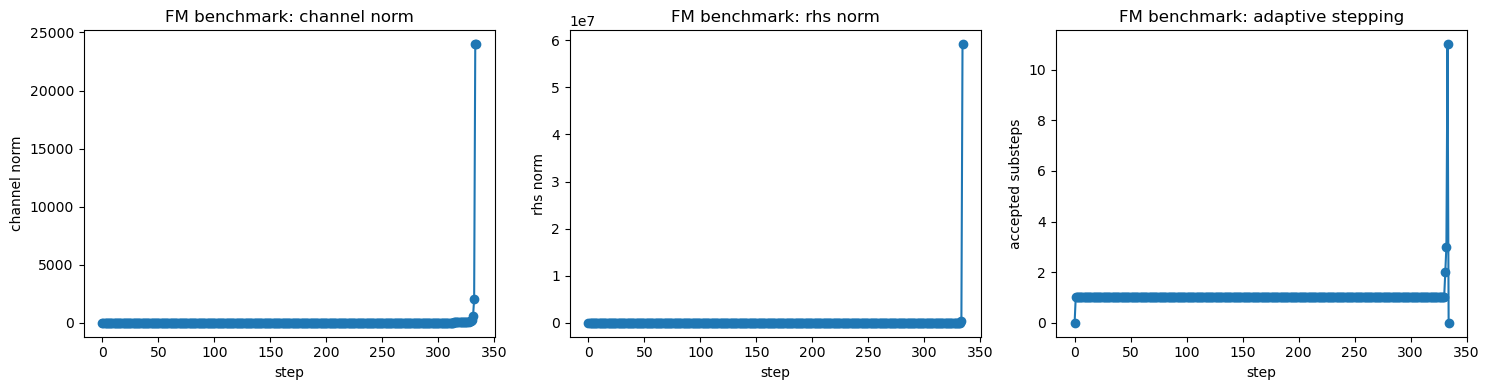

In [13]:

fm_result = run_case("FM benchmark", U=6.0, V=.0, flow_kwargs=FLOW_KWARGS)


===== Final-state mother-channel diagnosis across all Q =====

===== Q[0] = [0. 0.] =====
pp_mother_sz0            |eig|max = 50030.334
ph_mother_longitudinal   |eig|max = 974570.95
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 974570.95)

===== Q[1] = [0.         1.81379936] =====
pp_mother_sz0            |eig|max = 47616.632
ph_mother_longitudinal   |eig|max = 23730.463
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 47616.632)

===== Q[2] = [1.57079633 0.90689968] =====
pp_mother_sz0            |eig|max = 47799.477
ph_mother_longitudinal   |eig|max = 23730.463
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 47799.477)

===== Q[3] = [-1.57079633  0.90689968] =====
pp_mother_sz0            |eig|max = 47616.632
ph_mother_longitudinal   |eig|max = 23730.463
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 47616.632)
[{'Q_index': 0, 'Q_vec': array([0., 0.]), 'pp_mother_sz0': 50030.334230112196, 'ph_mother_longi

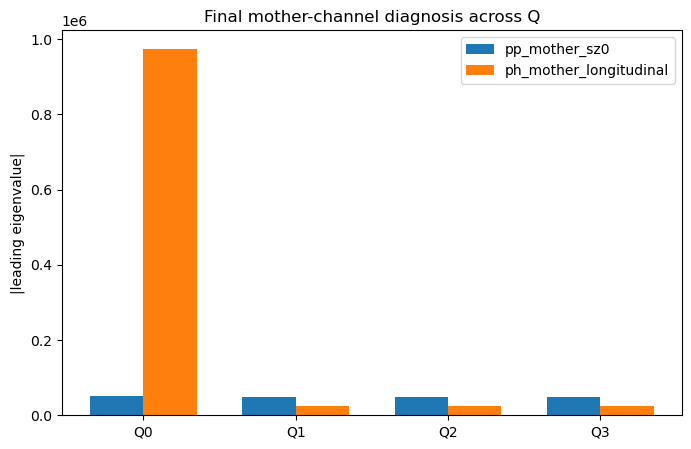


==== pp_mother_sz0 ====
Q = [0. 0.]
first |eig|max = 50030.334230112196
vec.real = [-0.10019007  0.16505728  0.15435835  0.16505728 -0.10019007  0.16505728
  0.15435835  0.16505728 -0.10019007  0.16505728  0.15435835  0.16505728
  0.16505728  0.15435835  0.16505728  0.16505728  0.15435835  0.16505728
  0.16505728  0.15435835  0.16505728  0.10019007 -0.16505728 -0.15435835
 -0.16505728  0.10019007 -0.16505728 -0.15435835 -0.16505728  0.10019007
 -0.16505728 -0.15435835 -0.16505728 -0.16505728 -0.15435835 -0.16505728
 -0.16505728 -0.15435835 -0.16505728 -0.16505728 -0.15435835 -0.16505728]
vec.abs  = [0.10019007 0.16505728 0.15435835 0.16505728 0.10019007 0.16505728
 0.15435835 0.16505728 0.10019007 0.16505728 0.15435835 0.16505728
 0.16505728 0.15435835 0.16505728 0.16505728 0.15435835 0.16505728
 0.16505728 0.15435835 0.16505728 0.10019007 0.16505728 0.15435835
 0.16505728 0.10019007 0.16505728 0.15435835 0.16505728 0.10019007
 0.16505728 0.15435835 0.16505728 0.16505728 0.15435835 0.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from channels import FullVertexChannelBuilder

# ----------------------------------------
# Choose Q list
# ----------------------------------------
Qs_to_check = DIAGNOSIS_QS

# If you want to test Q -> Q+G invariance, do it manually like this:
# shift = 5*np.array([np.pi, np.pi/np.sqrt(3)]) + np.array([0, 2*np.pi/np.sqrt(3)])
# Qs_to_check = [np.asarray(Q, dtype=float) + shift for Q in DIAGNOSIS_QS]

solver = fm_result["solver"]

# Build the diagnosis object from the CURRENT full vertex
builder = FullVertexChannelBuilder(
    gamma=solver.current_gamma_accessor(),
    patchsets=solver.patchsets,
    closure_map=solver.closure_map(),
    transfer_context=solver.transfer_context(),
    q_merge_tol_red=solver.q_merge_tol_red,
    q_key_decimals=solver.q_key_decimals,
)

mother_channels = [
    "pp_mother_sz0",
    "ph_mother_longitudinal",
]

print("===== Final-state mother-channel diagnosis across all Q =====")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    mothers = builder.build_mother_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    vals_dict = {}
    for name in mother_channels:
        k = mothers[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        row[name] = float(eigmax)
        print(f"{name:24s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    row["leading_geometry"] = lead_name
    row["leading_value"] = vals_dict[lead_name]
    Q_summary.append(row)

    print(f"--> leading mother channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")

print(Q_summary)

labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.35

pp_vals = [row["pp_mother_sz0"] for row in Q_summary]
ph_vals = [row["ph_mother_longitudinal"] for row in Q_summary]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pp_vals, width, label="pp_mother_sz0")
plt.bar(x + width/2, ph_vals, width, label="ph_mother_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final mother-channel diagnosis across Q")
plt.legend()
plt.show()

# ----------------------------------------
# Detailed printout at Q = 0
# ----------------------------------------
Q = np.array([0.0, 0.0], dtype=float)
mothers = builder.build_mother_kernel_dict(Q)

for name in ["pp_mother_sz0", "ph_mother_longitudinal"]:
    k = mothers[name]
    vals, vecs = k.eig(sort_by="abs")

    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("first |eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

    if len(vals) > 1:
        print(f"\n==== {name} ====")
        print("Q =", k.Q)
        print("second |eig|max =", abs(vals[1]))
        print("vec.real =", np.real(vecs[:, 1]))
        print("vec.abs  =", np.abs(vecs[:, 1]))


## 5. sBO benchmark: `U=6, V=6`

<!-- - dominant nearest-neighbor repulsion should favor **Pomeranchuk instability (PI)** with d-wave character. -->



===== Running case: sBO benchmark (U=1.0, V=3.0) =====
[DEBUG] entering step: T_old=50.00000000, dT=-1.91673796e-01
[DEBUG] leaving step: T_new=49.80832620, rhs_norm=0.17971421752785283, channel_norm=6.025784300964985, accepted_substeps=1, max_rel_update=0.00574108438179162, terminated_early=False
[DEBUG] entering step: T_old=49.80832620, dT=-1.90939019e-01
[DEBUG] leaving step: T_new=49.61738718, rhs_norm=0.18300179697818994, channel_norm=6.052045115136784, accepted_substeps=1, max_rel_update=0.005798777700787702, terminated_early=False
[DEBUG] entering step: T_old=49.61738718, dT=-1.90207059e-01
[DEBUG] leaving step: T_new=49.42718013, rhs_norm=0.18637609526101329, channel_norm=6.0787945308605265, accepted_substeps=1, max_rel_update=0.005857532171863385, terminated_early=False
[DEBUG] entering step: T_old=49.42718013, dT=-1.89477905e-01
[DEBUG] leaving step: T_new=49.23770222, rhs_norm=0.18984015613708216, channel_norm=6.106045046519333, accepted_substeps=1, max_rel_update=0.0059173

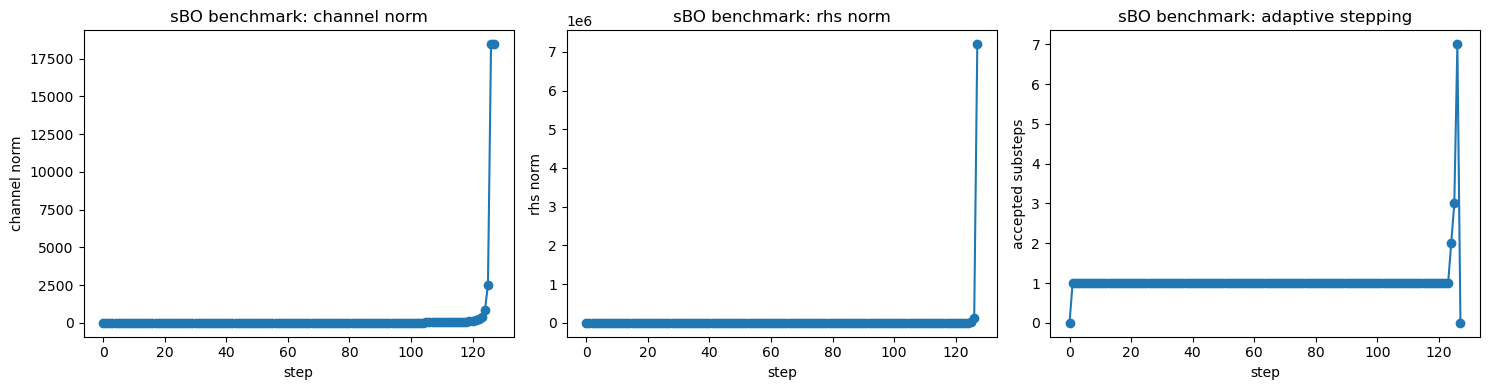

In [15]:

sBO_result = run_case("sBO benchmark", U=1.0, V=3.0, flow_kwargs=FLOW_KWARGS)


===== Final-state mother-channel diagnosis across all Q =====

===== Q[0] = [0. 0.] =====
pp_mother_sz0            |eig|max = 36912.841
ph_mother_longitudinal   |eig|max = 755075.73
--> leading mother channel at this Q: ph_mother_longitudinal  (|eig|max = 755075.73)

===== Q[1] = [0.         1.81379936] =====
pp_mother_sz0            |eig|max = 36920.711
ph_mother_longitudinal   |eig|max = 18250.195
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 36920.711)

===== Q[2] = [1.57079633 0.90689968] =====
pp_mother_sz0            |eig|max = 36924.674
ph_mother_longitudinal   |eig|max = 18250.236
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 36924.674)

===== Q[3] = [-1.57079633  0.90689968] =====
pp_mother_sz0            |eig|max = 36922.511
ph_mother_longitudinal   |eig|max = 18250.236
--> leading mother channel at this Q: pp_mother_sz0  (|eig|max = 36922.511)
[{'Q_index': 0, 'Q_vec': array([0., 0.]), 'pp_mother_sz0': 36912.84076318627, 'ph_mother_longit

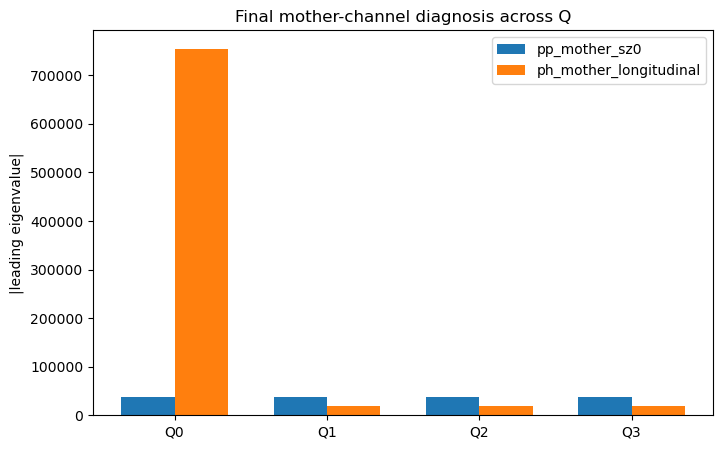


==== pp_mother_sz0 ====
Q = [0. 0.]
first |eig|max = 36912.84076318627
vec.real = [-1.76327627e-14 -2.41759394e-01 -9.64708597e-03 -2.57398023e-01
 -1.39657623e-14 -2.57398023e-01 -9.64708597e-03 -2.41759394e-01
 -5.83635279e-15 -1.43383116e-02  8.59622883e-13  1.43383116e-02
  2.41759394e-01  9.64708597e-03  2.57398023e-01  2.57398023e-01
  9.64708597e-03  2.41759394e-01  1.43383116e-02 -8.24170489e-13
 -1.43383116e-02  1.74650067e-14 -2.41759394e-01 -9.64708597e-03
 -2.57398023e-01  1.39900751e-14 -2.57398023e-01 -9.64708597e-03
 -2.41759394e-01  5.86103065e-15 -1.43383116e-02  8.24275999e-13
  1.43383116e-02  2.41759394e-01  9.64708597e-03  2.57398023e-01
  2.57398023e-01  9.64708597e-03  2.41759394e-01  1.43383116e-02
 -8.59586768e-13 -1.43383116e-02]
vec.abs  = [1.76327627e-14 2.41759394e-01 9.64708597e-03 2.57398023e-01
 1.39657623e-14 2.57398023e-01 9.64708597e-03 2.41759394e-01
 5.83635279e-15 1.43383116e-02 8.59622883e-13 1.43383116e-02
 2.41759394e-01 9.64708597e-03 2.573980

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from channels import FullVertexChannelBuilder

# ----------------------------------------
# Choose Q list
# ----------------------------------------
Qs_to_check = DIAGNOSIS_QS

# If you want to test Q -> Q+G invariance, do it manually like this:
# shift = 5*np.array([np.pi, np.pi/np.sqrt(3)]) + np.array([0, 2*np.pi/np.sqrt(3)])
# Qs_to_check = [np.asarray(Q, dtype=float) + shift for Q in DIAGNOSIS_QS]

solver = sBO_result["solver"]

# Build the diagnosis object from the CURRENT full vertex
builder = FullVertexChannelBuilder(
    gamma=solver.current_gamma_accessor(),
    patchsets=solver.patchsets,
    closure_map=solver.closure_map(),
    transfer_context=solver.transfer_context(),
    q_merge_tol_red=solver.q_merge_tol_red,
    q_key_decimals=solver.q_key_decimals,
)

mother_channels = [
    "pp_mother_sz0",
    "ph_mother_longitudinal",
]

print("===== Final-state mother-channel diagnosis across all Q =====")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    mothers = builder.build_mother_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    vals_dict = {}
    for name in mother_channels:
        k = mothers[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        row[name] = float(eigmax)
        print(f"{name:24s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    row["leading_geometry"] = lead_name
    row["leading_value"] = vals_dict[lead_name]
    Q_summary.append(row)

    print(f"--> leading mother channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")

print(Q_summary)

labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.35

pp_vals = [row["pp_mother_sz0"] for row in Q_summary]
ph_vals = [row["ph_mother_longitudinal"] for row in Q_summary]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pp_vals, width, label="pp_mother_sz0")
plt.bar(x + width/2, ph_vals, width, label="ph_mother_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final mother-channel diagnosis across Q")
plt.legend()
plt.show()

# ----------------------------------------
# Detailed printout at Q = 0
# ----------------------------------------
Q = np.array([0.0, 0.0], dtype=float)
mothers = builder.build_mother_kernel_dict(Q)

for name in ["pp_mother_sz0", "ph_mother_longitudinal"]:
    k = mothers[name]
    vals, vecs = k.eig(sort_by="abs")

    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("first |eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

    if len(vals) > 1:
        print(f"\n==== {name} ====")
        print("Q =", k.Q)
        print("second |eig|max =", abs(vals[1]))
        print("vec.real =", np.real(vecs[:, 1]))
        print("vec.abs  =", np.abs(vecs[:, 1]))

# Save & Load

In [18]:
# ============================================================
# SAVE fm_result and sBO_result
# ============================================================

import os
import gzip

try:
    import cloudpickle as cpkl
    _PICKLER_NAME = "cloudpickle"
except Exception:
    import pickle as cpkl
    _PICKLER_NAME = "pickle"

SAVE_PATH = "saved_frg_results.pkl.gz"

payload = {
    "fm_result": fm_result,
    "sBO_result": sBO_result,
}

with gzip.open(SAVE_PATH, "wb") as f:
    cpkl.dump(payload, f)

print(f"[SAVE] done with {_PICKLER_NAME}")
print(f"[SAVE] file = {os.path.abspath(SAVE_PATH)}")
print(f"[SAVE] keys = {list(payload.keys())}")

[SAVE] done with cloudpickle
[SAVE] file = C:\Users\mli826\Github_rep\functional-RG-Kagome-\functional-RG-Kagome-\saved_frg_results.pkl.gz
[SAVE] keys = ['fm_result', 'sBO_result']


In [7]:
# ============================================================
# LOAD fm_result and sBO_result
# ============================================================

import os
import gzip

try:
    import cloudpickle as cpkl
    _PICKLER_NAME = "cloudpickle"
except Exception:
    import pickle as cpkl
    _PICKLER_NAME = "pickle"

SAVE_PATH = "saved_frg_results.pkl.gz"

if not os.path.exists(SAVE_PATH):
    raise FileNotFoundError(f"Cannot find saved file: {os.path.abspath(SAVE_PATH)}")

with gzip.open(SAVE_PATH, "rb") as f:
    loaded_payload = cpkl.load(f)

fm_result = loaded_payload["fm_result"]
sBO_result = loaded_payload["sBO_result"]

print(f"[LOAD] loaded with {_PICKLER_NAME}")
print(f"[LOAD] keys = {list(loaded_payload.keys())}")
print(f"[LOAD] fm_result type = {type(fm_result)}")
print(f"[LOAD] sBO_result type = {type(sBO_result)}")

# ============================================================
# SANITY CHECK after load
# ============================================================

for name, obj in [("fm_result", fm_result), ("sBO_result", sBO_result)]:
    print(f"\n===== {name} =====")
    if isinstance(obj, dict):
        print("dict keys:", list(obj.keys()))
        if "solver" in obj:
            solver = obj["solver"]
            print("solver type:", type(solver))
            print("T_start, T_stop =", getattr(solver, "T_start", None), getattr(solver, "T_stop", None))
            print("diagnosis_Qs =", getattr(solver, "diagnosis_Qs", None))
    else:
        print("type:", type(obj))

[LOAD] loaded with pickle
[LOAD] keys = ['fm_result', 'sBO_result']
[LOAD] fm_result type = <class 'dict'>
[LOAD] sBO_result type = <class 'dict'>

===== fm_result =====
dict keys: ['case_name', 'U', 'V', 'interaction', 'solver', 'history', 'final_record']
solver type: <class 'frg_flow.FRGFlowSolver'>
T_start, T_stop = 30.0 0.5
diagnosis_Qs = [array([0., 0.]), array([1.57079633, 2.72069905]), array([0.        , 1.81379936]), array([1.57079633, 0.90689968])]

===== sBO_result =====
dict keys: ['case_name', 'U', 'V', 'interaction', 'solver', 'history', 'final_record']
solver type: <class 'frg_flow.FRGFlowSolver'>
T_start, T_stop = 30.0 0.5
diagnosis_Qs = [array([0., 0.]), array([1.57079633, 2.72069905]), array([0.        , 1.81379936]), array([1.57079633, 0.90689968])]


# Debug

===== Qs used in this inspection =====
Q0(found idx=0, dist=0.000e+00) -> [0. 0.]
QM1(found idx=1, dist=0.000e+00) -> [0.           1.8137993642]

INSPECTING Q0(found idx=0, dist=0.000e+00) : Q = [0. 0.]

----- Mother-kernel leading eigenvalues -----
pp_mother_sz0            |eig|max = 36912.841 | herm_res = 1.600e-01
ph_mother_longitudinal   |eig|max = 755075.73 | herm_res = 9.043e-02

----- ph_mother_longitudinal 4 mother blocks -----
mother uu->uu  | shape=(21, 21) | max|M|=18460.1 | mean|diag|=2.61839e-37 | mean|off|=18421.4 | std|off|=66.2295 | diag/off=1.42139e-41
mother uu->dd  | shape=(21, 21) | max|M|=18460.3 | mean|diag|=18216.1 | mean|off|=18421.5 | std|off|=66.3363 | diag/off=0.988848
mother dd->uu  | shape=(21, 21) | max|M|=18460.3 | mean|diag|=18216.1 | mean|off|=18421.5 | std|off|=66.3363 | diag/off=0.988848
mother dd->dd  | shape=(21, 21) | max|M|=18460.1 | mean|diag|=5.65551e-37 | mean|off|=18421.4 | std|off|=66.2295 | diag/off=3.07008e-41

----- Raw phd blocks -----
p

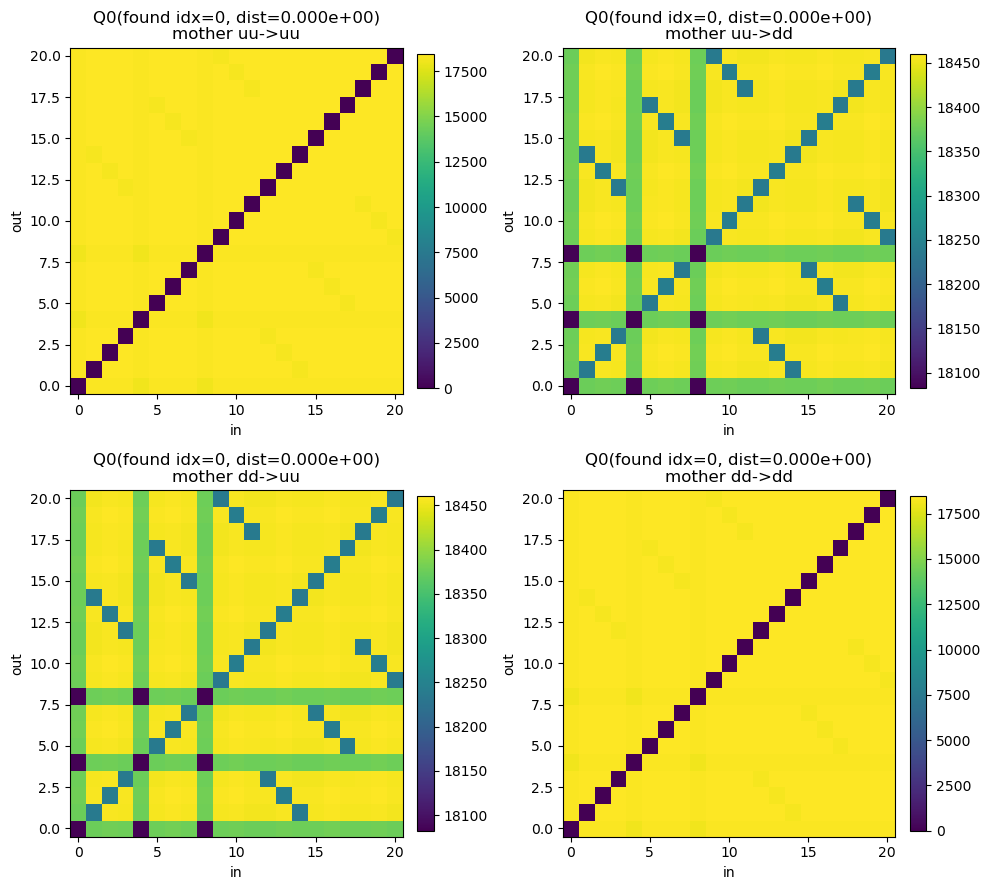

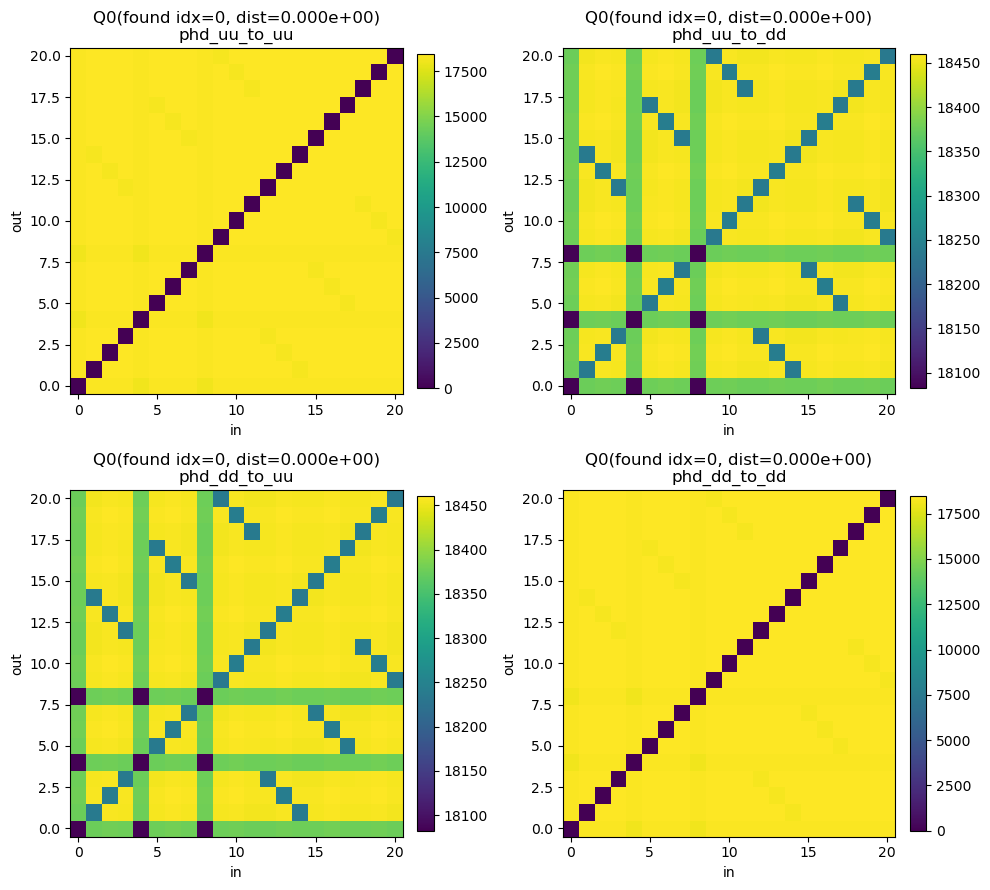

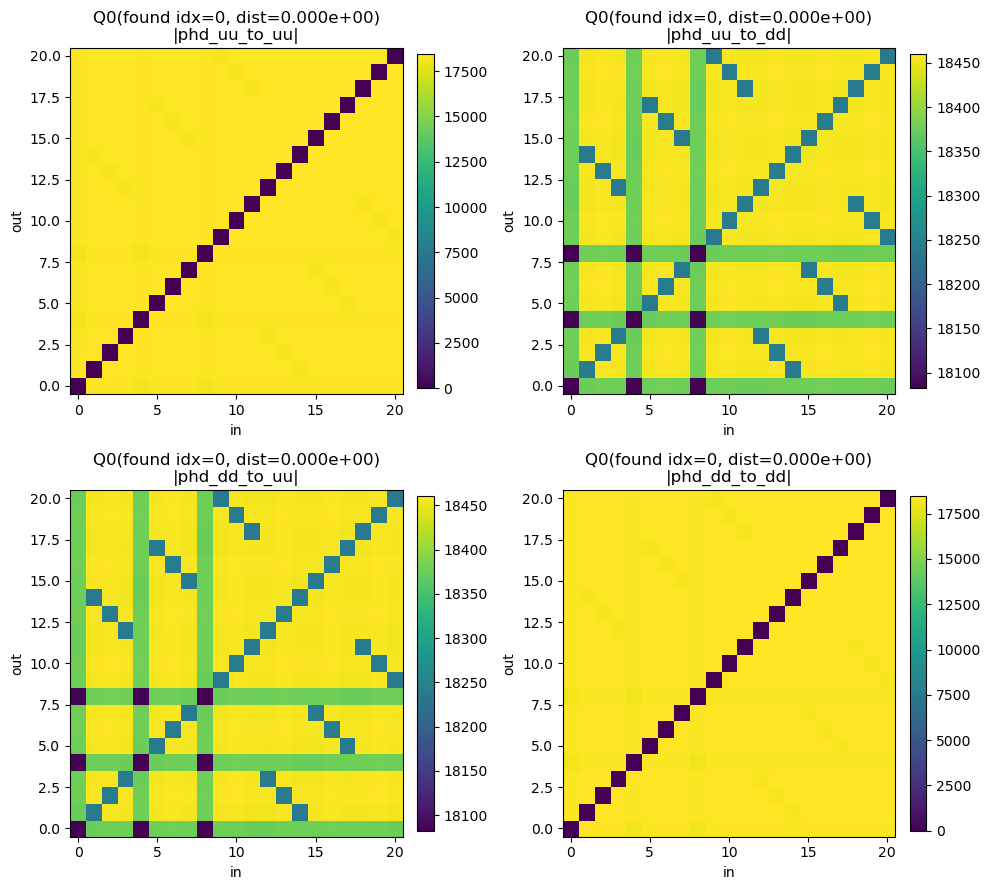

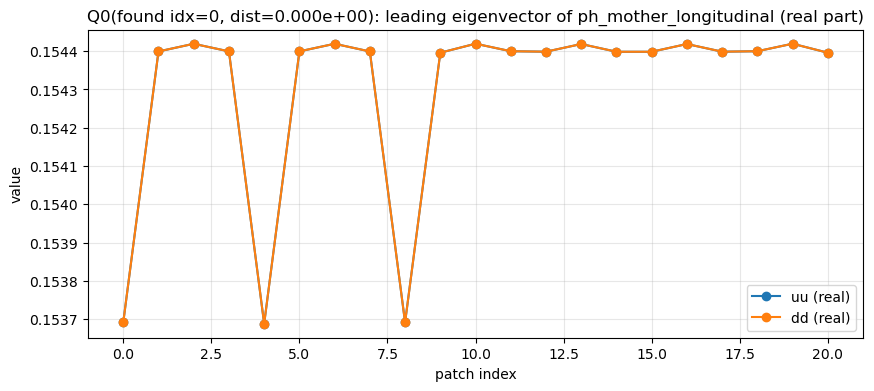

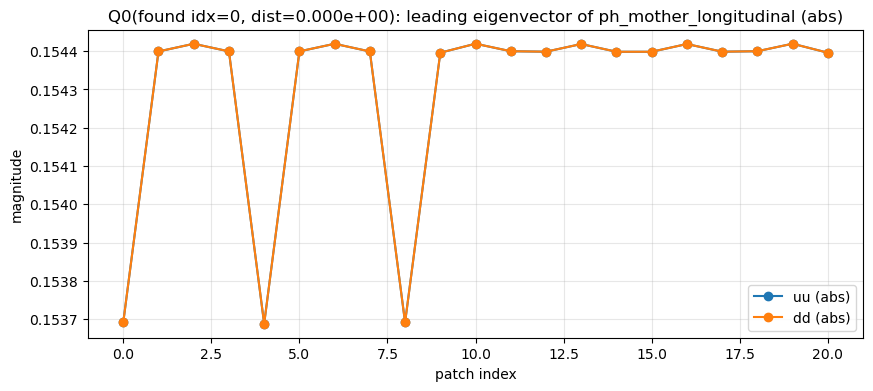


INSPECTING QM1(found idx=1, dist=0.000e+00) : Q = [0.           1.8137993642]

----- Mother-kernel leading eigenvalues -----
pp_mother_sz0            |eig|max = 36920.711 | herm_res = 7.034e+00
ph_mother_longitudinal   |eig|max = 18250.195 | herm_res = 1.320e-02

----- ph_mother_longitudinal 4 mother blocks -----
mother uu->uu  | shape=(21, 21) | max|M|=18243 | mean|diag|=6933.62 | mean|off|=0.220946 | std|off|=0.734746 | diag/off=31381.5
mother uu->dd  | shape=(21, 21) | max|M|=1.20483 | mean|diag|=0.201657 | mean|off|=0.0712869 | std|off|=0.25581 | diag/off=2.8288
mother dd->uu  | shape=(21, 21) | max|M|=1.20483 | mean|diag|=0.201657 | mean|off|=0.0712869 | std|off|=0.25581 | diag/off=2.8288
mother dd->dd  | shape=(21, 21) | max|M|=18243 | mean|diag|=6933.62 | mean|off|=0.220946 | std|off|=0.734746 | diag/off=31381.5

----- Raw phd blocks -----
phd_uu_to_uu   | shape=(21, 21) | max|M|=18243 | mean|diag|=6933.62 | mean|off|=0.220946 | std|off|=0.734746 | diag/off=31381.5
phd_uu_to_dd

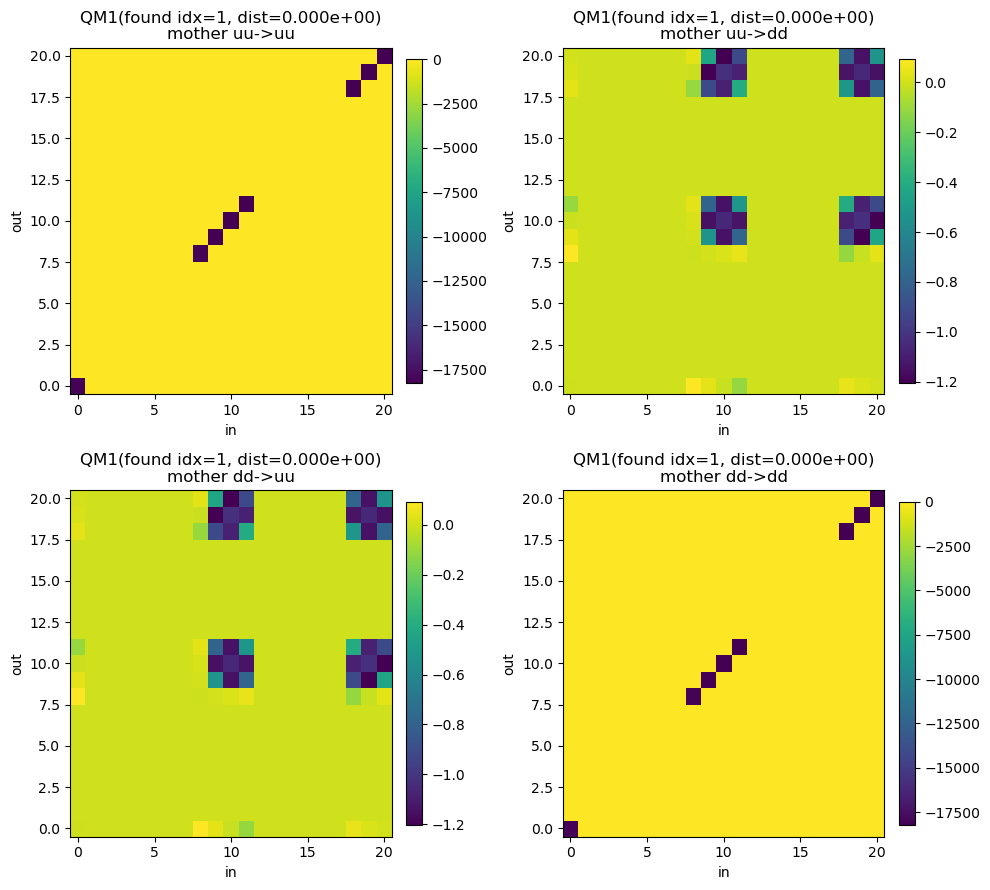

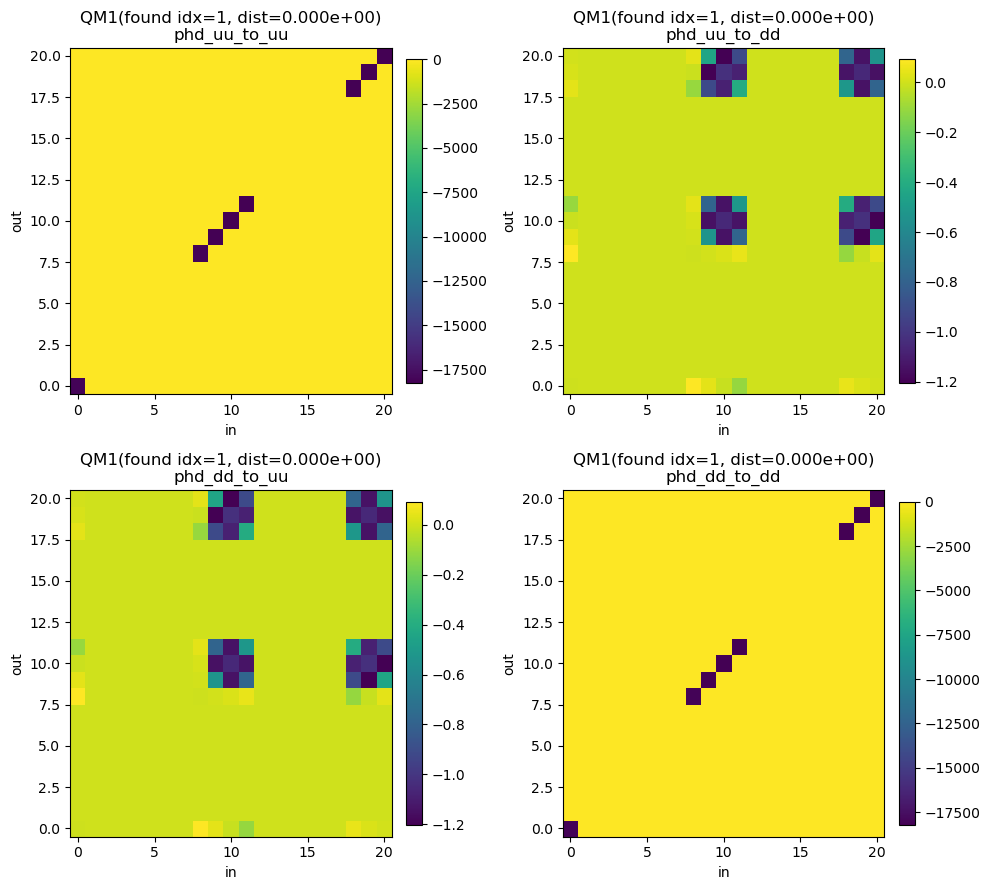

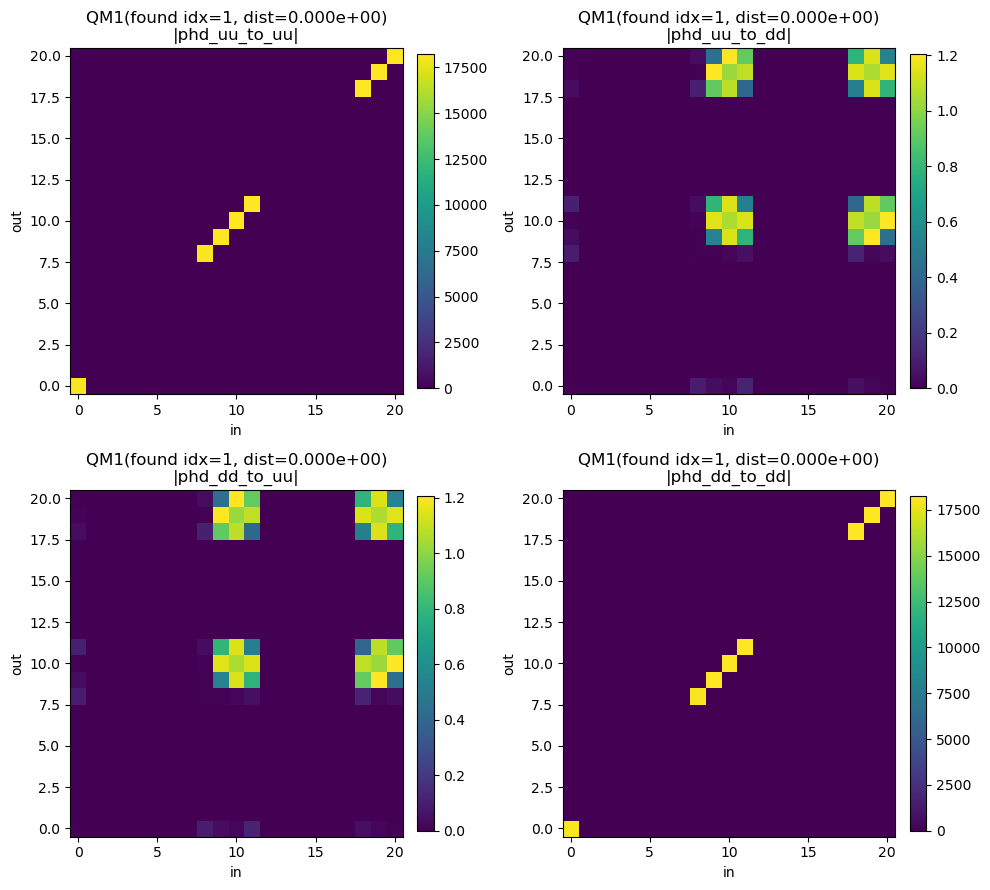

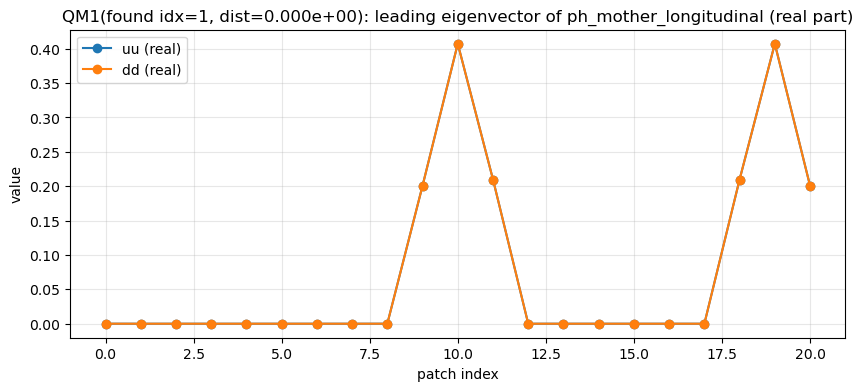

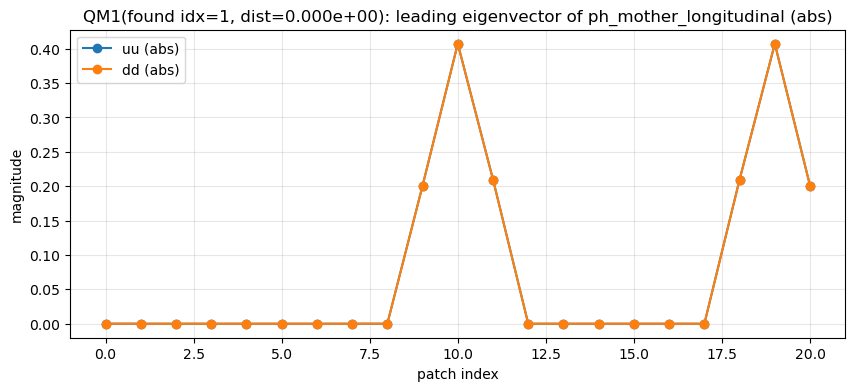

In [24]:
import numpy as np
import matplotlib.pyplot as plt

from channels import FullVertexChannelBuilder
from frg_kernel import canonicalize_q_for_patchsets

# ============================================================
# Inspect final mother-kernel / raw-block structure for sBO_result
# Works for your patch-24 pipeline notebook
# ============================================================

solver = sBO_result["solver"]

builder = FullVertexChannelBuilder(
    gamma=solver.current_gamma_accessor(),
    patchsets=solver.patchsets,
    closure_map=solver.closure_map(),
    transfer_context=solver.transfer_context(),
    q_merge_tol_red=solver.q_merge_tol_red,
    q_key_decimals=solver.q_key_decimals,
)

# ------------------------------------------------------------
# Build a convenient Q dictionary
# ------------------------------------------------------------
ps_ref = solver.patchsets["up"]
b1 = np.asarray(ps_ref.b1, dtype=float)

Q0 = np.zeros(2, dtype=float)
QM1_guess = canonicalize_q_for_patchsets(solver.patchsets, 0.5 * b1)

# If DIAGNOSIS_QS exists, try to identify the Q closest to Q0 / QM1_guess
Q_dict = {"Q0": Q0, "QM1_guess": QM1_guess}

if "DIAGNOSIS_QS" in globals():
    Qs_all = [np.asarray(Q, dtype=float) for Q in DIAGNOSIS_QS]

    def _closest_Q(target, Q_list):
        dists = [np.linalg.norm(np.asarray(Q) - np.asarray(target)) for Q in Q_list]
        idx = int(np.argmin(dists))
        return idx, np.asarray(Q_list[idx], dtype=float), dists[idx]

    i0, q0_found, d0 = _closest_Q(Q0, Qs_all)
    iM, qM_found, dM = _closest_Q(QM1_guess, Qs_all)

    Q_dict = {
        f"Q0(found idx={i0}, dist={d0:.3e})": q0_found,
        f"QM1(found idx={iM}, dist={dM:.3e})": qM_found,
    }

print("===== Qs used in this inspection =====")
for tag, Q in Q_dict.items():
    print(f"{tag:30s} -> {np.array2string(Q, precision=10)}")


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def summarize_matrix(mat):
    mat = np.asarray(mat)
    abs_mat = np.abs(mat)
    diag = np.diag(mat)
    off = mat.copy()
    np.fill_diagonal(off, 0.0)

    diag_abs_mean = float(np.mean(np.abs(diag))) if diag.size else 0.0

    if mat.shape[0] > 1:
        mask = ~np.eye(mat.shape[0], dtype=bool)
        off_abs_mean = float(np.mean(abs_mat[mask]))
        off_abs_std  = float(np.std(abs_mat[mask]))
    else:
        off_abs_mean = 0.0
        off_abs_std  = 0.0

    return {
        "shape": mat.shape,
        "max_abs": float(np.max(abs_mat)),
        "diag_abs_mean": diag_abs_mean,
        "off_abs_mean": off_abs_mean,
        "off_abs_std": off_abs_std,
        "diag/off_mean": (diag_abs_mean / off_abs_mean) if off_abs_mean > 1e-14 else np.inf,
    }


def print_block_summary(name, mat):
    s = summarize_matrix(mat)
    print(
        f"{name:14s} | shape={s['shape']} "
        f"| max|M|={s['max_abs']:.6g} "
        f"| mean|diag|={s['diag_abs_mean']:.6g} "
        f"| mean|off|={s['off_abs_mean']:.6g} "
        f"| std|off|={s['off_abs_std']:.6g} "
        f"| diag/off={s['diag/off_mean']:.6g}"
    )


def show_matrix(ax, mat, title):
    im = ax.imshow(np.real(mat), origin="lower", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("in")
    ax.set_ylabel("out")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


# ------------------------------------------------------------
# Main inspection loop
# ------------------------------------------------------------
for Q_tag, Q in Q_dict.items():
    print("\n" + "=" * 100)
    print(f"INSPECTING {Q_tag} : Q = {np.array2string(Q, precision=10)}")
    print("=" * 100)

    mothers = builder.build_mother_kernel_dict(Q)
    raws = builder.build_raw_block_dict(Q)

    # -----------------------------
    # Mother kernels
    # -----------------------------
    print("\n----- Mother-kernel leading eigenvalues -----")
    for name in ["pp_mother_sz0", "ph_mother_longitudinal"]:
        k = mothers[name]
        vals, vecs = k.eig(sort_by="abs")
        print(f"{name:24s} |eig|max = {abs(vals[0]):.8g} | herm_res = {k.hermitian_residual():.3e}")

    ph_mother = mothers["ph_mother_longitudinal"]
    Np = ph_mother.Npatch

    # Split 2Np x 2Np mother into 4 Np x Np blocks
    ph_uu_uu = ph_mother.block("uu", "uu")
    ph_uu_dd = ph_mother.block("uu", "dd")
    ph_dd_uu = ph_mother.block("dd", "uu")
    ph_dd_dd = ph_mother.block("dd", "dd")

    print("\n----- ph_mother_longitudinal 4 mother blocks -----")
    print_block_summary("mother uu->uu", ph_uu_uu)
    print_block_summary("mother uu->dd", ph_uu_dd)
    print_block_summary("mother dd->uu", ph_dd_uu)
    print_block_summary("mother dd->dd", ph_dd_dd)

    # -----------------------------
    # Raw phd blocks
    # -----------------------------
    raw_names = [
        "phd_uu_to_uu",
        "phd_uu_to_dd",
        "phd_dd_to_uu",
        "phd_dd_to_dd",
    ]

    print("\n----- Raw phd blocks -----")
    for name in raw_names:
        print_block_summary(name, raws[name].matrix)

    # -----------------------------
    # Plot mother 4-block structure
    # -----------------------------
    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    show_matrix(axes[0, 0], ph_uu_uu, f"{Q_tag}\nmother uu->uu")
    show_matrix(axes[0, 1], ph_uu_dd, f"{Q_tag}\nmother uu->dd")
    show_matrix(axes[1, 0], ph_dd_uu, f"{Q_tag}\nmother dd->uu")
    show_matrix(axes[1, 1], ph_dd_dd, f"{Q_tag}\nmother dd->dd")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Plot raw phd blocks directly
    # -----------------------------
    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    for ax, name in zip(axes.ravel(), raw_names):
        show_matrix(ax, raws[name].matrix, f"{Q_tag}\n{name}")
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Plot absolute value too
    # -----------------------------
    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    for ax, name in zip(axes.ravel(), raw_names):
        mat = np.abs(raws[name].matrix)
        im = ax.imshow(mat, origin="lower", aspect="auto")
        ax.set_title(f"{Q_tag}\n|{name}|")
        ax.set_xlabel("in")
        ax.set_ylabel("out")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Leading eigenvector of ph mother
    # -----------------------------
    vals, vecs = ph_mother.eig(sort_by="abs")
    v0 = vecs[:, 0]
    v0_split = ph_mother.split_vector_by_block(v0)

    plt.figure(figsize=(10, 4))
    for lbl in ph_mother.basis_labels:
        plt.plot(np.real(v0_split[lbl]), marker="o", label=f"{lbl} (real)")
    plt.title(f"{Q_tag}: leading eigenvector of ph_mother_longitudinal (real part)")
    plt.xlabel("patch index")
    plt.ylabel("value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 4))
    for lbl in ph_mother.basis_labels:
        plt.plot(np.abs(v0_split[lbl]), marker="o", label=f"{lbl} (abs)")
    plt.title(f"{Q_tag}: leading eigenvector of ph_mother_longitudinal (abs)")
    plt.xlabel("patch index")
    plt.ylabel("magnitude")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [38]:
import numpy as np

from frg_flow import FRGFlowSolver, BareVertexFromInteraction

# ------------------------------------------------------------
# Use your existing solver only as a template for:
#   - patchsets
#   - Q catalogs
#   - numerical flow settings
# ------------------------------------------------------------
template_solver = sBO_result["solver"]
patchsets = template_solver.patchsets

# Rebuild interaction with U=0, V=3 using the same kagome bond vectors
base_interaction = template_solver.bare_gamma.interaction
InteractionCls = type(base_interaction)

fresh_interaction = InteractionCls(
    U=0.0,
    V=8.0,
    delta1=np.array(base_interaction.delta1, dtype=float),
    delta2=np.array(base_interaction.delta2, dtype=float),
    delta3=np.array(base_interaction.delta3, dtype=float),
)

fresh_bare_gamma = BareVertexFromInteraction(fresh_interaction, patchsets)

# ------------------------------------------------------------
# Fresh early-flow solver
# You can tune T_stop / n_steps if you want longer or shorter early flow
# ------------------------------------------------------------
solver_V3_early = FRGFlowSolver(
    patchsets=patchsets,
    bare_gamma=fresh_bare_gamma,
    spin_blocks=template_solver.spin_blocks,
    pp_Qs=[np.array(q, dtype=float) for q in template_solver.pp_grid.q_list],
    ph_Qs=[np.array(q, dtype=float) for q in template_solver.phd_grid.q_list],
    phc_Qs=[np.array(q, dtype=float) for q in template_solver.phc_grid.q_list],
    T_start=20.0,
    T_stop=.5,              # early-flow window; change if you want
    n_steps=100,                # gives 8 actual updates
    temperature_grid="linear",
    nfreq=template_solver.nfreq,
    include_explicit_T_prefactor=template_solver.include_explicit_T_prefactor,
    max_relative_update=template_solver.max_relative_update,
    min_substep_fraction=template_solver.min_substep_fraction,
    channel_divergence_threshold=1e12,   # keep this huge; we do not want early termination here
    diagnose_every=1,
    q_merge_tol_red=template_solver.q_merge_tol_red,
    q_key_decimals=template_solver.q_key_decimals,
)

print("Fresh solver built.")
print("T path =", solver_V3_early.temperature_path)
print("Npatch =", solver_V3_early.Npatch)
print("spin blocks =", solver_V3_early.spin_blocks)

Fresh solver built.
T path = [20.         19.8030303  19.60606061 19.40909091 19.21212121 19.01515152
 18.81818182 18.62121212 18.42424242 18.22727273 18.03030303 17.83333333
 17.63636364 17.43939394 17.24242424 17.04545455 16.84848485 16.65151515
 16.45454545 16.25757576 16.06060606 15.86363636 15.66666667 15.46969697
 15.27272727 15.07575758 14.87878788 14.68181818 14.48484848 14.28787879
 14.09090909 13.89393939 13.6969697  13.5        13.3030303  13.10606061
 12.90909091 12.71212121 12.51515152 12.31818182 12.12121212 11.92424242
 11.72727273 11.53030303 11.33333333 11.13636364 10.93939394 10.74242424
 10.54545455 10.34848485 10.15151515  9.95454545  9.75757576  9.56060606
  9.36363636  9.16666667  8.96969697  8.77272727  8.57575758  8.37878788
  8.18181818  7.98484848  7.78787879  7.59090909  7.39393939  7.1969697
  7.          6.8030303   6.60606061  6.40909091  6.21212121  6.01515152
  5.81818182  5.62121212  5.42424242  5.22727273  5.03030303  4.83333333
  4.63636364  4.4393939

In [42]:
import numpy as np
import matplotlib.pyplot as plt

from channels import FullVertexChannelBuilder
from frg_kernel import compute_rhs_block_fullvertex, build_pp_internal_cache_vec, build_ph_internal_cache_vec

Q0 = np.zeros(2, dtype=float)

RAW_NAMES = [
    "phd_uu_to_uu",
    "phd_uu_to_dd",
    "phd_dd_to_uu",
    "phd_dd_to_dd",
]

def mat_summary(mat):
    mat = np.asarray(mat)
    diag = np.diag(mat)
    mask = ~np.eye(mat.shape[0], dtype=bool)
    off = mat[mask]
    return {
        "max_abs": float(np.max(np.abs(mat))),
        "diag_abs_mean": float(np.mean(np.abs(diag))) if diag.size else 0.0,
        "off_abs_mean": float(np.mean(np.abs(off))) if off.size else 0.0,
        "off_abs_std": float(np.std(np.abs(off))) if off.size else 0.0,
    }

def print_raw_summary(raw_dict, title=""):
    if title:
        print(title)
    for nm in RAW_NAMES:
        s = mat_summary(raw_dict[nm].matrix)
        print(
            f"{nm:14s} | max={s['max_abs']:.6g} | "
            f"diag_mean={s['diag_abs_mean']:.6g} | "
            f"off_mean={s['off_abs_mean']:.6g} | "
            f"off_std={s['off_abs_std']:.6g}"
        )

def build_raw_blocks_from_gamma(solver, gamma_accessor, Q):
    builder = FullVertexChannelBuilder(
        gamma=gamma_accessor,
        patchsets=solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
        q_merge_tol_red=solver.q_merge_tol_red,
        q_key_decimals=solver.q_key_decimals,
    )
    return builder.build_raw_block_dict(Q)

def build_uncompressed_internal_caches(solver, T):
    cfg = solver._flow_config(T)

    pp_internal_by_iq = {}
    phd_internal_by_iq = {}
    phc_internal_by_iq = {}

    for iq, _Q in enumerate(solver.pp_grid.q_list):
        shift_cache = {(sa, sb): solver._pp_qminus[(iq, sa, sb)] for sa, sb in solver._internal_spin_pairs}
        pp_internal_by_iq[iq] = build_pp_internal_cache_vec(solver.patchsets, cfg, shift_cache=shift_cache)

    for iq, _Q in enumerate(solver.phd_grid.q_list):
        shift_cache = {(sa, sb): solver._ph_kplus[(iq, sa, sb)] for sa, sb in solver._internal_spin_pairs}
        phd_internal_by_iq[iq] = build_ph_internal_cache_vec(solver.patchsets, cfg, shift_cache=shift_cache)

    for iq, _Q in enumerate(solver.phc_grid.q_list):
        shift_cache = {(sa, sb): solver._phc_kplus[(iq, sa, sb)] for sa, sb in solver._internal_spin_pairs}
        phc_internal_by_iq[iq] = build_ph_internal_cache_vec(solver.patchsets, cfg, shift_cache=shift_cache)

    return pp_internal_by_iq, phd_internal_by_iq, phc_internal_by_iq

def build_rhs_split_blocks(solver, T):
    pp_internal_by_iq, phd_internal_by_iq, phc_internal_by_iq = build_uncompressed_internal_caches(solver, T)

    rhs_parts = {}
    for key in solver.spin_blocks:
        s1, s2, s3, s4 = key
        rhs_parts[key] = compute_rhs_block_fullvertex(
            gamma=solver.current_gamma_accessor(),
            patchsets=solver.patchsets,
            spin_block=key,
            p4_index=solver.state.gamma_blocks[key].p4_index,
            pp_q_index=solver._pp_q_index[(s1, s2)],
            phd_q_index=solver._phd_q_index_plus[(s3, s1)],  # function expects [p3,p1], same table object
            phc_q_index=solver._phc_q_index_plus[(s3, s2)],  # function expects [p3,p2], same table object
            pp_internal_caches_by_iq=pp_internal_by_iq,
            phd_internal_caches_by_iq=phd_internal_by_iq,
            phc_internal_caches_by_iq=phc_internal_by_iq,
            allowed_spin_blocks=solver.spin_blocks,
        )
    return rhs_parts

class PartAccessor:
    def __init__(self, solver, rhs_parts_by_spinblock, part):
        self.solver = solver
        self.rhs_parts_by_spinblock = rhs_parts_by_spinblock
        self.part = part

    def __call__(self, p1, s1, p2, s2, p3, s3, p4, s4):
        key = tuple(map(str, (s1, s2, s3, s4)))
        # keys in solver.spin_blocks are already normalized strings
        for true_key in self.solver.spin_blocks:
            if true_key == key:
                blk = self.rhs_parts_by_spinblock[true_key][self.part]
                p4_expected = int(self.solver.state.gamma_blocks[true_key].p4_index[p1, p2, p3])
                if p4_expected < 0 or int(p4) != p4_expected:
                    return 0.0 + 0.0j
                return complex(blk[p1, p2, p3])
        return 0.0 + 0.0j

def collect_snapshot(solver, T, label):
    snap = {"label": label, "T": float(T)}

    # current flowed vertex -> raw Q=0 blocks
    snap["raw_now"] = build_raw_blocks_from_gamma(solver, solver.current_gamma_accessor(), Q0)

    # RHS split -> project each part into the same raw Q=0 basis
    rhs_parts = build_rhs_split_blocks(solver, T)
    snap["rhs_blocks"] = rhs_parts

    snap["rhs_raw"] = {}
    for part in ["pp", "phd", "phc", "total"]:
        part_accessor = PartAccessor(solver, rhs_parts, part)
        snap["rhs_raw"][part] = build_raw_blocks_from_gamma(solver, part_accessor, Q0)

    return snap

def plot_raw_2x2(raw_dict, suptitle=""):
    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    for ax, nm in zip(axes.ravel(), RAW_NAMES):
        mat = np.real(raw_dict[nm].matrix)
        im = ax.imshow(mat, origin="lower", aspect="auto")
        ax.set_title(nm)
        ax.set_xlabel("in")
        ax.set_ylabel("out")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if suptitle:
        fig.suptitle(suptitle, y=1.02)
    plt.tight_layout()
    plt.show()
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Choose representative steps automatically
# ------------------------------------------------------------
def make_representative_step_ids(n_updates, manual_steps=None, include_log_dense=True):
    """
    Return sorted step ids in [0, n_updates], where:
      0          = initial
      n_updates  = final
    """
    keep = {0, n_updates}

    if manual_steps is not None:
        for s in manual_steps:
            if 0 <= int(s) <= n_updates:
                keep.add(int(s))

    if include_log_dense and n_updates >= 8:
        # logarithmically denser at early stage, sparser later
        guess = np.unique(
            np.round(
                np.geomspace(1, max(1, n_updates), num=min(10, n_updates))
            ).astype(int)
        )
        for s in guess:
            if 0 <= int(s) <= n_updates:
                keep.add(int(s))

    return sorted(keep)


# ------------------------------------------------------------
# Compact numerical evolution summaries
# ------------------------------------------------------------
def extract_metric_series(snapshots, raw_name):
    Ts = [snap["T"] for snap in snapshots]
    diag_means = []
    off_means = []
    off_stds = []
    max_abs = []

    for snap in snapshots:
        s = mat_summary(snap["raw_now"][raw_name].matrix)
        diag_means.append(s["diag_abs_mean"])
        off_means.append(s["off_abs_mean"])
        off_stds.append(s["off_abs_std"])
        max_abs.append(s["max_abs"])

    return {
        "T": np.array(Ts, dtype=float),
        "diag_mean": np.array(diag_means, dtype=float),
        "off_mean": np.array(off_means, dtype=float),
        "off_std": np.array(off_stds, dtype=float),
        "max_abs": np.array(max_abs, dtype=float),
    }


def plot_metric_evolution(snapshots):
    names = [
        "phd_uu_to_uu",
        "phd_uu_to_dd",
        "phd_dd_to_uu",
        "phd_dd_to_dd",
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, nm in zip(axes.ravel(), names):
        data = extract_metric_series(snapshots, nm)
        ax.plot(data["T"], data["diag_mean"], marker="o", label="diag_mean")
        ax.plot(data["T"], data["off_mean"], marker="s", label="off_mean")
        ax.plot(data["T"], data["off_std"], marker="^", label="off_std")
        ax.set_title(nm)
        ax.set_xlabel("T")
        ax.set_ylabel("value")
        ax.invert_xaxis()
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Plot selected snapshots only
# ------------------------------------------------------------
def plot_selected_current_snapshots(selected_snapshots):
    for snap in selected_snapshots:
        plot_raw_2x2(
            snap["raw_now"],
            suptitle=f"Current raw ph-Q0 blocks | {snap['label']} | T={snap['T']:.6f}"
        )


def plot_selected_rhs_snapshots(selected_snapshots, parts=("pp", "phd", "phc", "total")):
    for snap in selected_snapshots:
        for part in parts:
            plot_raw_2x2(
                snap["rhs_raw"][part],
                suptitle=f"RHS projected to raw ph-Q0 blocks | part={part} | {snap['label']} | T={snap['T']:.6f}"
            )


# ------------------------------------------------------------
# Side-by-side compare one snapshot across rhs parts
# ------------------------------------------------------------
def plot_rhs_part_comparison_for_block(snap, raw_name="phd_uu_to_uu"):
    parts = ["pp", "phd", "phc", "total"]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, part in zip(axes, parts):
        mat = np.real(snap["rhs_raw"][part][raw_name].matrix)
        im = ax.imshow(mat, origin="lower", aspect="auto")
        ax.set_title(f"{part} | {raw_name}")
        ax.set_xlabel("in")
        ax.set_ylabel("out")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"RHS part comparison | {snap['label']} | T={snap['T']:.6f}", y=1.05)
    plt.tight_layout()
    plt.show()

In [49]:
snapshots_V3_long = []
flow_records_V3_long = []

temps = np.asarray(solver_V3_early.temperature_path, dtype=float)
n_updates = len(temps) - 1

# ------------------------------------------------------------
# Choose representative steps
# You can edit this list freely
# 0 = init, n_updates = final
# ------------------------------------------------------------
rep_step_ids = make_representative_step_ids(
    n_updates,
    manual_steps=[0, 1, 2, 5, 10, 20, 40, 60, 80, n_updates],
    include_log_dense=False,
)

print("Representative step ids:", rep_step_ids)
print("Corresponding temperatures:")
for sid in rep_step_ids:
    print(f"  step_id={sid:3d}  T={temps[sid]:.6f}")

# ------------------------------------------------------------
# Initial snapshot
# ------------------------------------------------------------
if 0 in rep_step_ids:
    snap0 = collect_snapshot(solver_V3_early, temps[0], label="init")
    snap0["step_id"] = 0
    snapshots_V3_long.append(snap0)

    print(f"\n[init] T={temps[0]:.6f}")
    print_raw_summary(snap0["raw_now"], title="Current raw Q=0 blocks:")
    print("-" * 100)

# ------------------------------------------------------------
# Full flow
# ------------------------------------------------------------
solver_V3_early.history = []

for i in range(n_updates):
    T_old = float(temps[i])
    T_new = float(temps[i + 1])
    dT = T_new - T_old

    rec = solver_V3_early.step(T_old, dT)
    flow_records_V3_long.append(rec)

    step_id = i + 1

    if step_id in rep_step_ids:
        label = "final" if step_id == n_updates else f"step_{step_id}"
        snap = collect_snapshot(solver_V3_early, T_new, label=label)
        snap["step_id"] = step_id
        snapshots_V3_long.append(snap)

        print(f"[{label}] step_id={step_id} | T_old={T_old:.6f} -> T_new={T_new:.6f} | rhs_norm={rec.rhs_norm:.6g} | channel_norm={rec.channel_norm:.6g}")
        print_raw_summary(snap["raw_now"], title="Current raw Q=0 blocks:")
        print("-" * 100)

print(f"\nDone. Stored {len(snapshots_V3_long)} representative snapshots out of {n_updates+1} total states.")

Representative step ids: [0, 1, 2, 5, 10, 20, 40, 60, 80, 99]
Corresponding temperatures:
  step_id=  0  T=20.000000
  step_id=  1  T=19.803030
  step_id=  2  T=19.606061
  step_id=  5  T=19.015152
  step_id= 10  T=18.030303
  step_id= 20  T=16.060606
  step_id= 40  T=12.121212
  step_id= 60  T=8.181818
  step_id= 80  T=4.242424
  step_id= 99  T=0.500000

[init] T=20.000000
Current raw Q=0 blocks:
phd_uu_to_uu   | max=143.585 | diag_mean=1.13623e-35 | off_mean=139.775 | off_std=3.20734
phd_uu_to_dd   | max=143.586 | diag_mean=133.921 | off_mean=139.542 | off_std=2.97464
phd_dd_to_uu   | max=143.586 | diag_mean=133.921 | off_mean=139.542 | off_std=2.97464
phd_dd_to_dd   | max=143.585 | diag_mean=7.76596e-36 | off_mean=139.775 | off_std=3.20734
----------------------------------------------------------------------------------------------------
[DEBUG] entering step: T_old=20.00000000, dT=-1.96969697e-01
[DEBUG] leaving step: T_new=19.80303030, rhs_norm=981.4326800055627, channel_norm=336

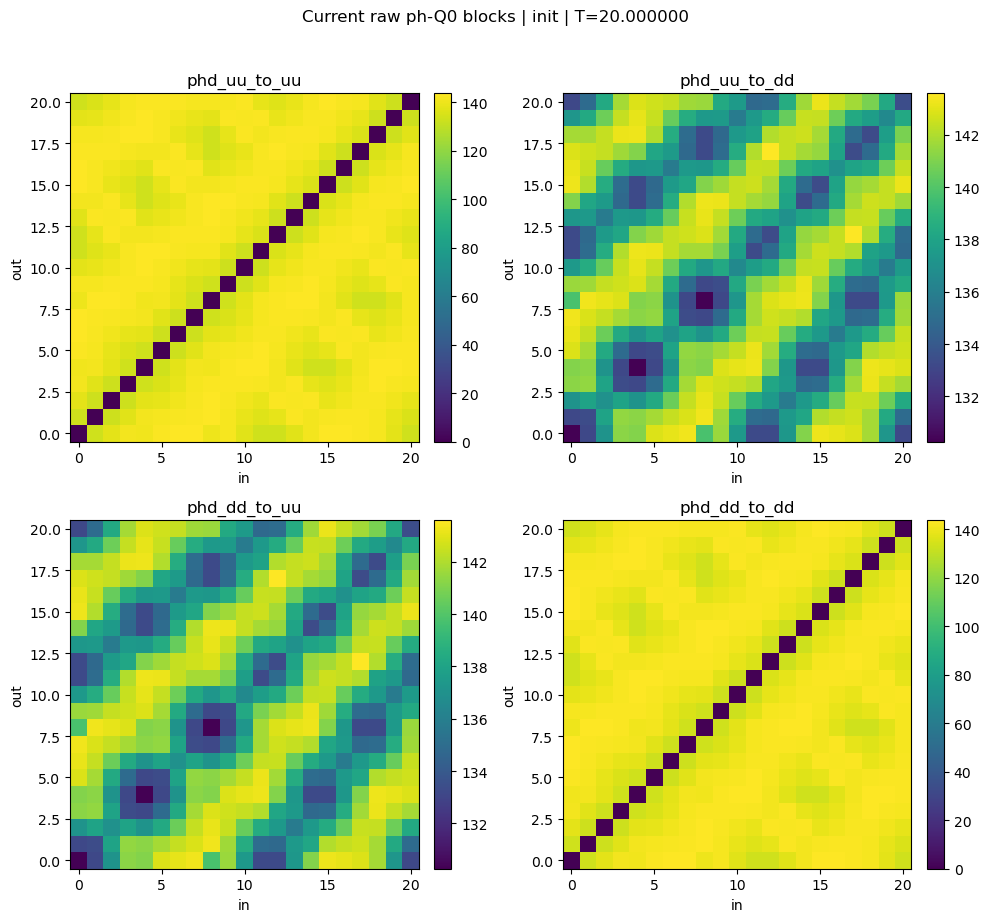

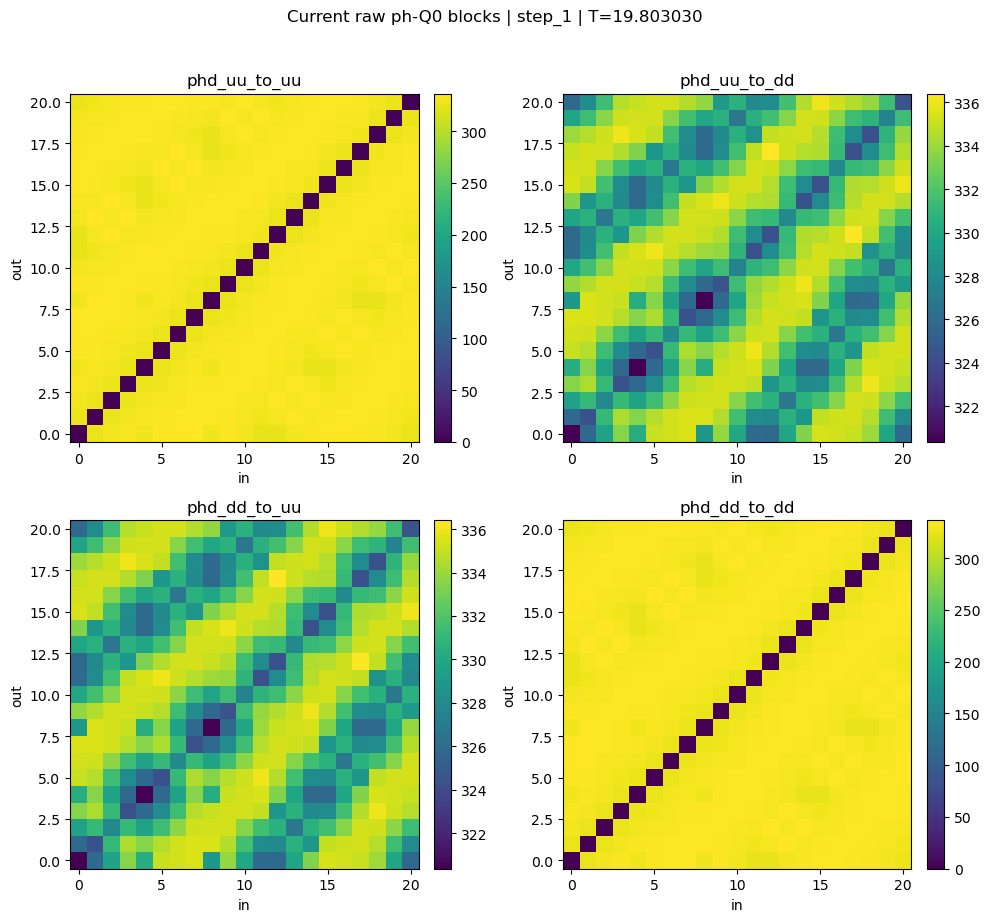

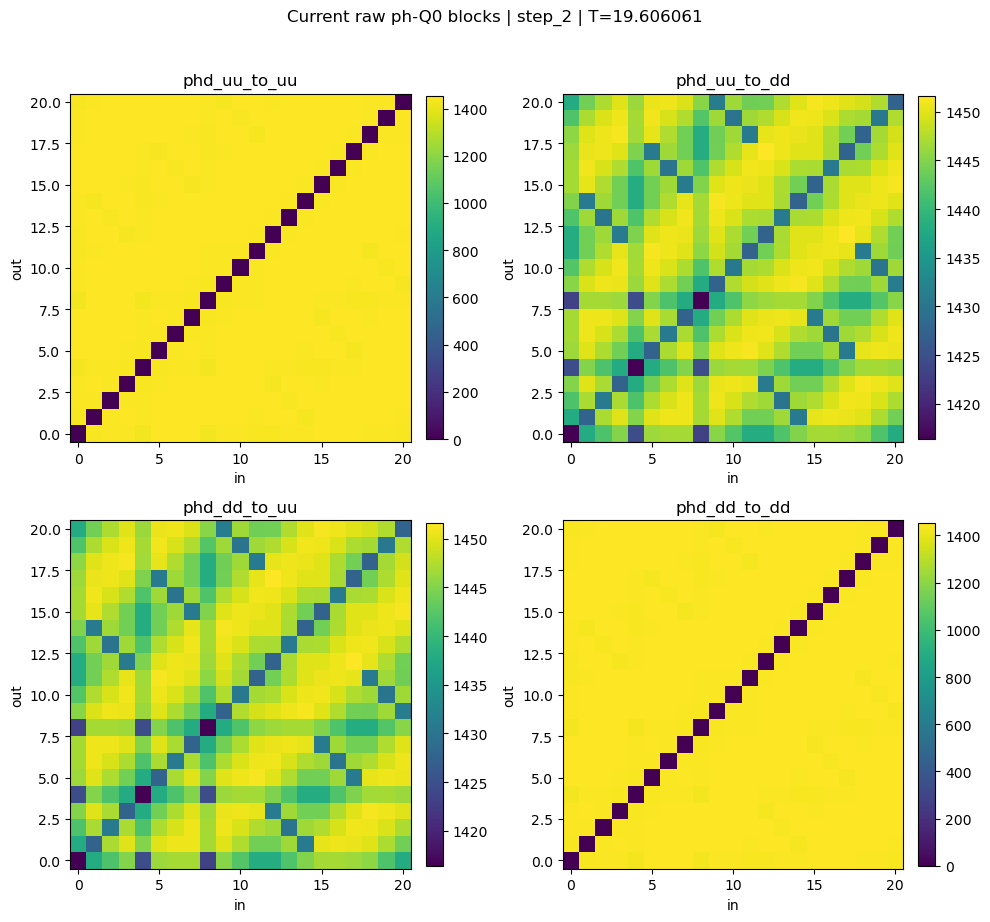

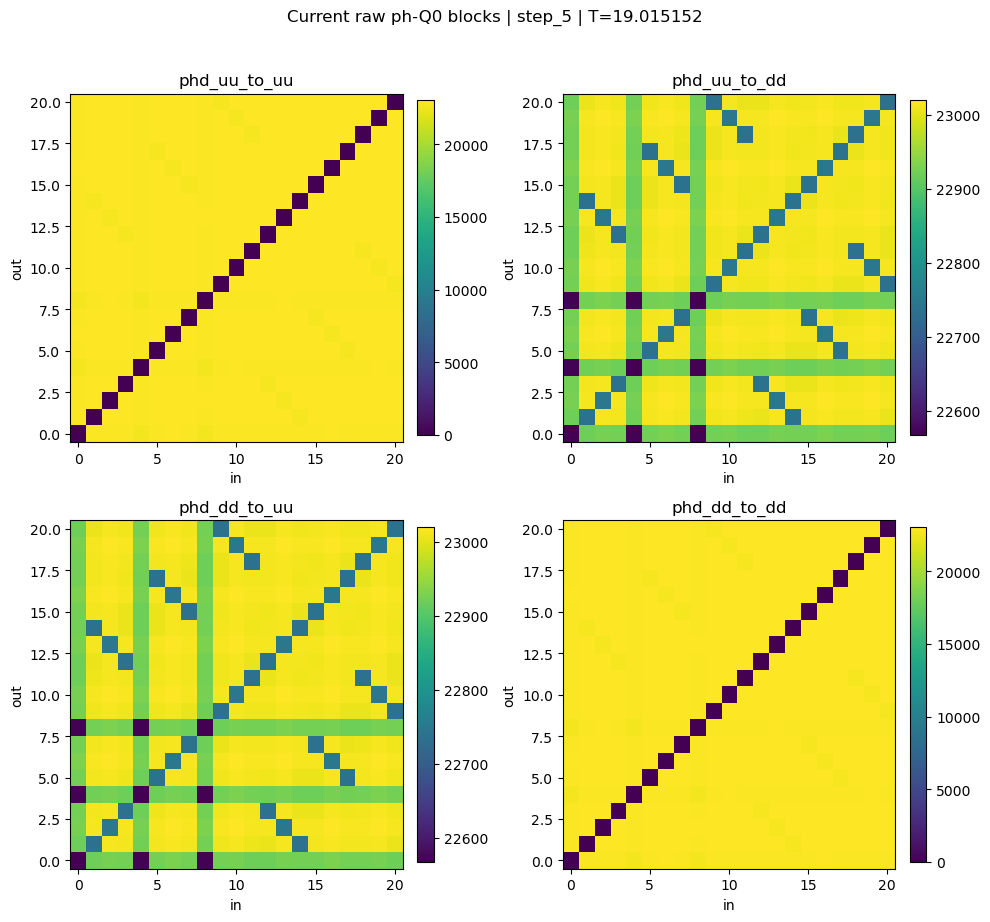

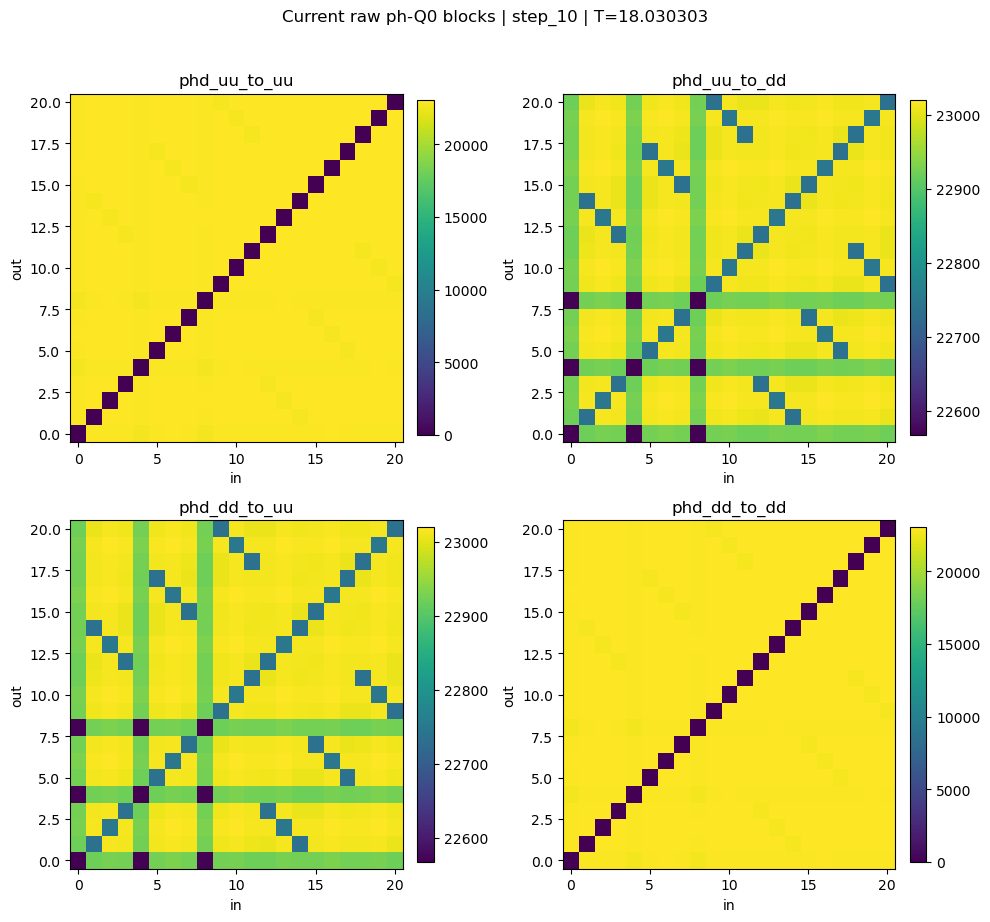

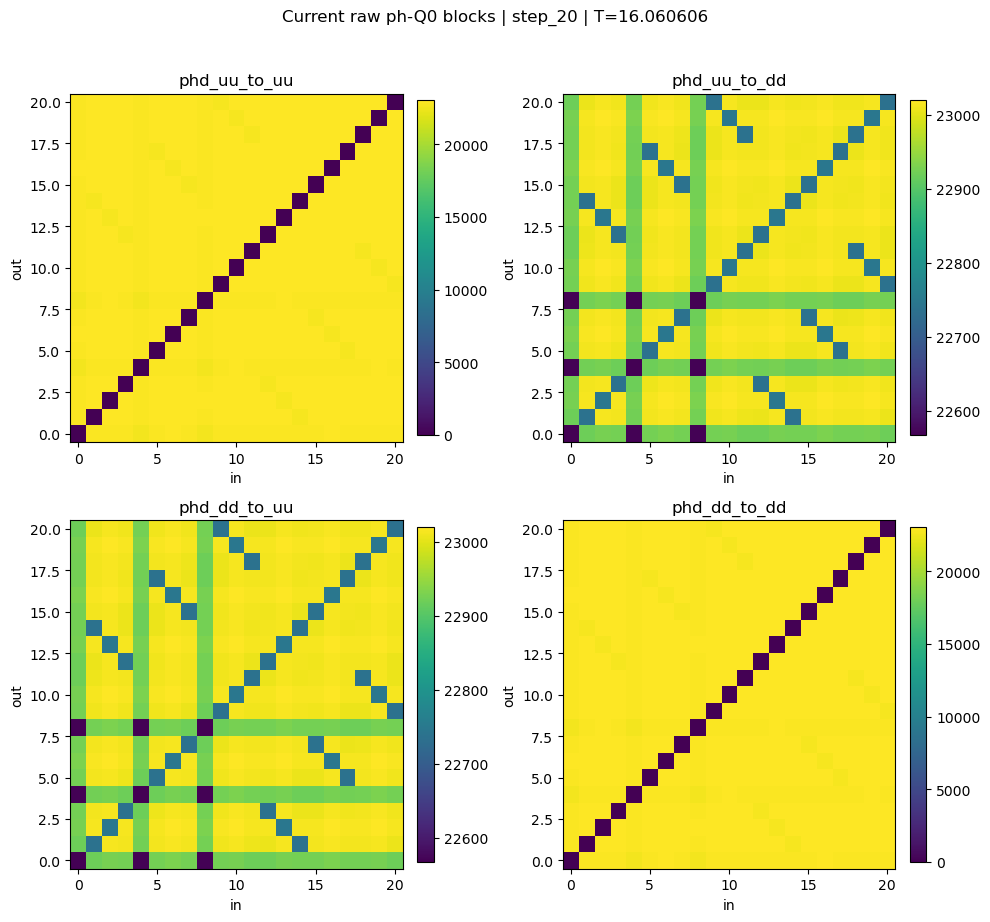

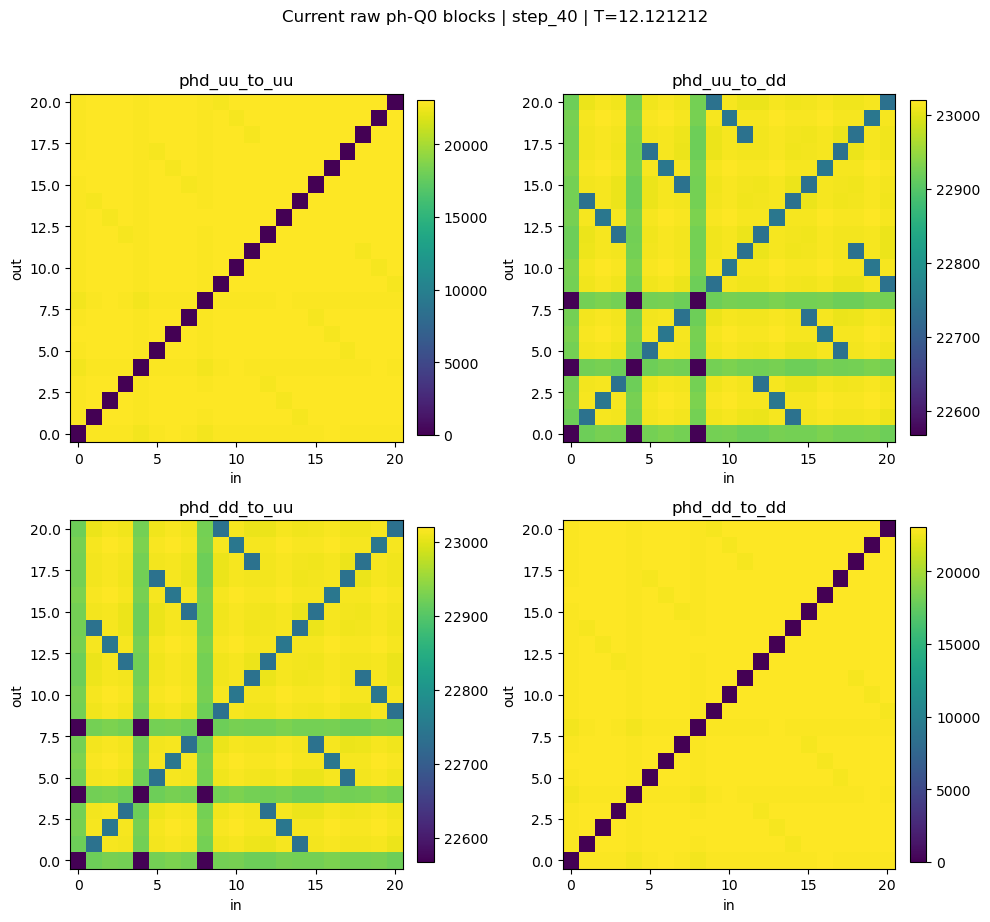

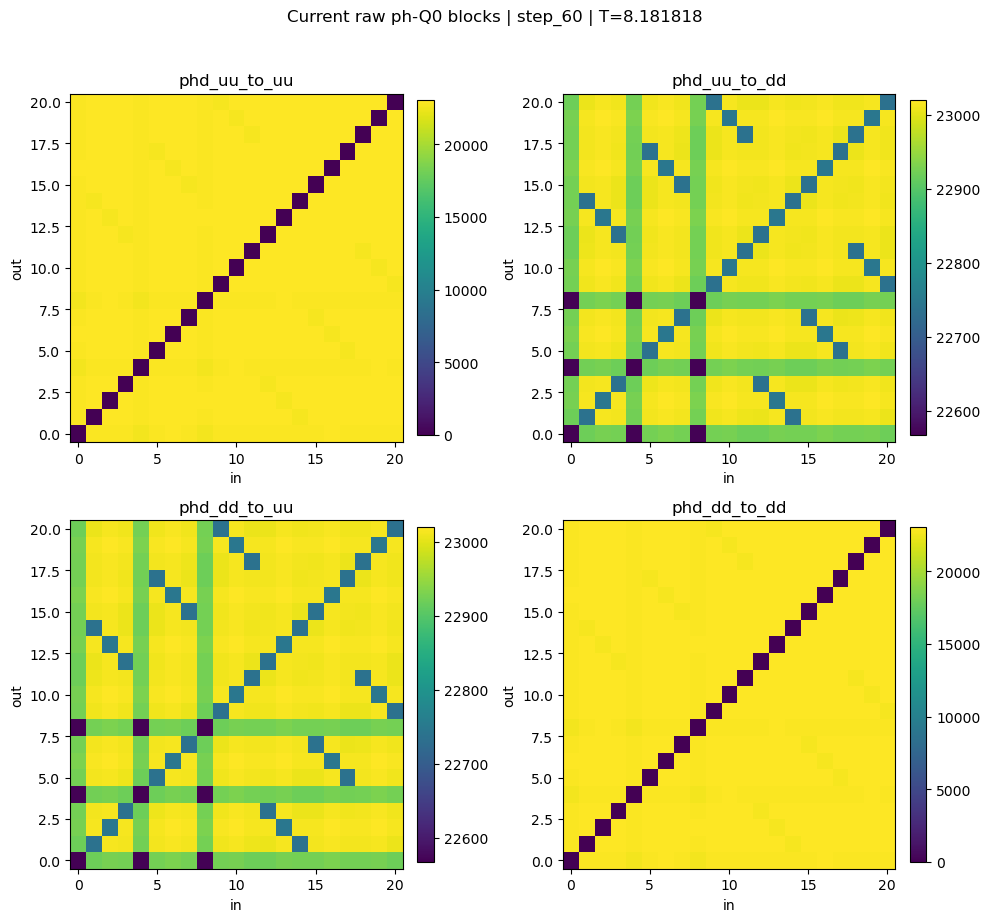

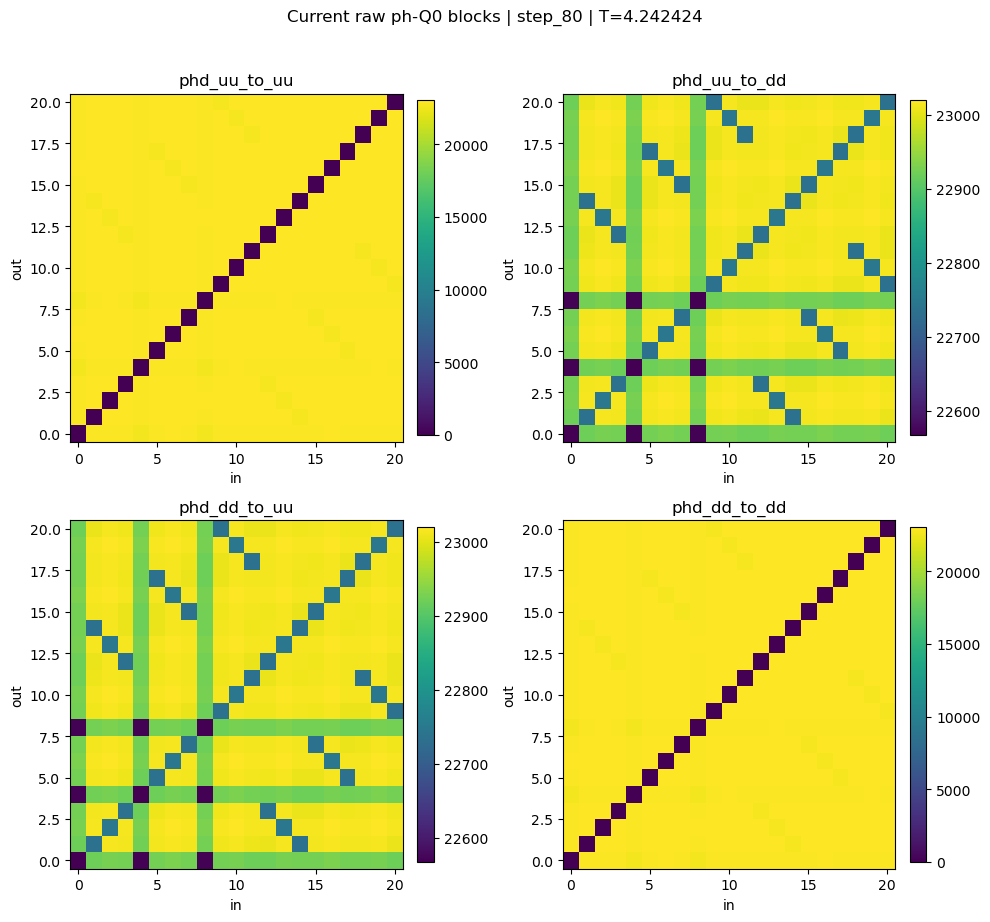

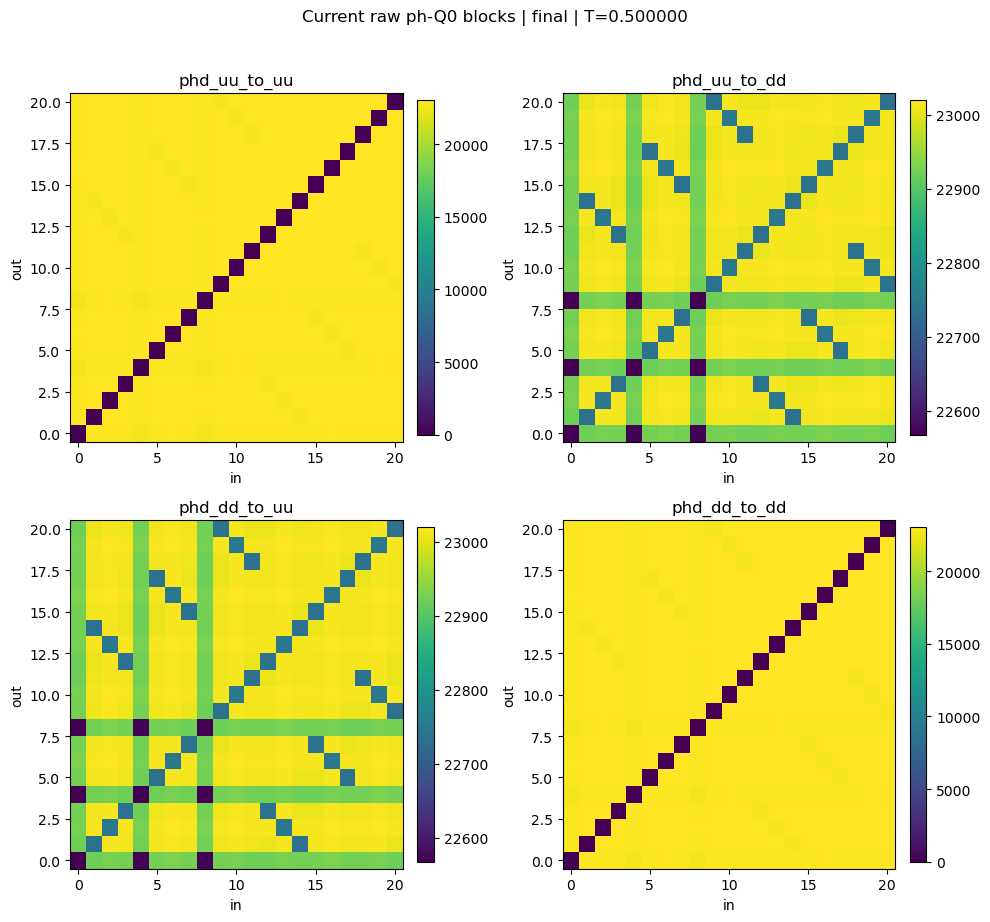

In [53]:
for snap in snapshots_V3_long:
    plot_raw_2x2(
        snap["raw_now"],
        suptitle=f"Current raw ph-Q0 blocks | {snap['label']} | T={snap['T']:.6f}"
    )

Inspect RHS contributions at snapshot: step_2 | step_id=2 | T=19.606061

===== Current vertex kernel at the SAME snapshot =====
Current raw Q=0 blocks
phd_uu_to_uu   | max=1451.58 | diag_mean=1.29429e-35 | off_mean=1446.2 | off_std=5.17428
phd_uu_to_dd   | max=1451.58 | diag_mean=1426.93 | off_mean=1446.01 | off_std=5.37018
phd_dd_to_uu   | max=1451.58 | diag_mean=1426.93 | off_mean=1446.01 | off_std=5.37018
phd_dd_to_dd   | max=1451.58 | diag_mean=8.44337e-36 | off_mean=1446.2 | off_std=5.17428


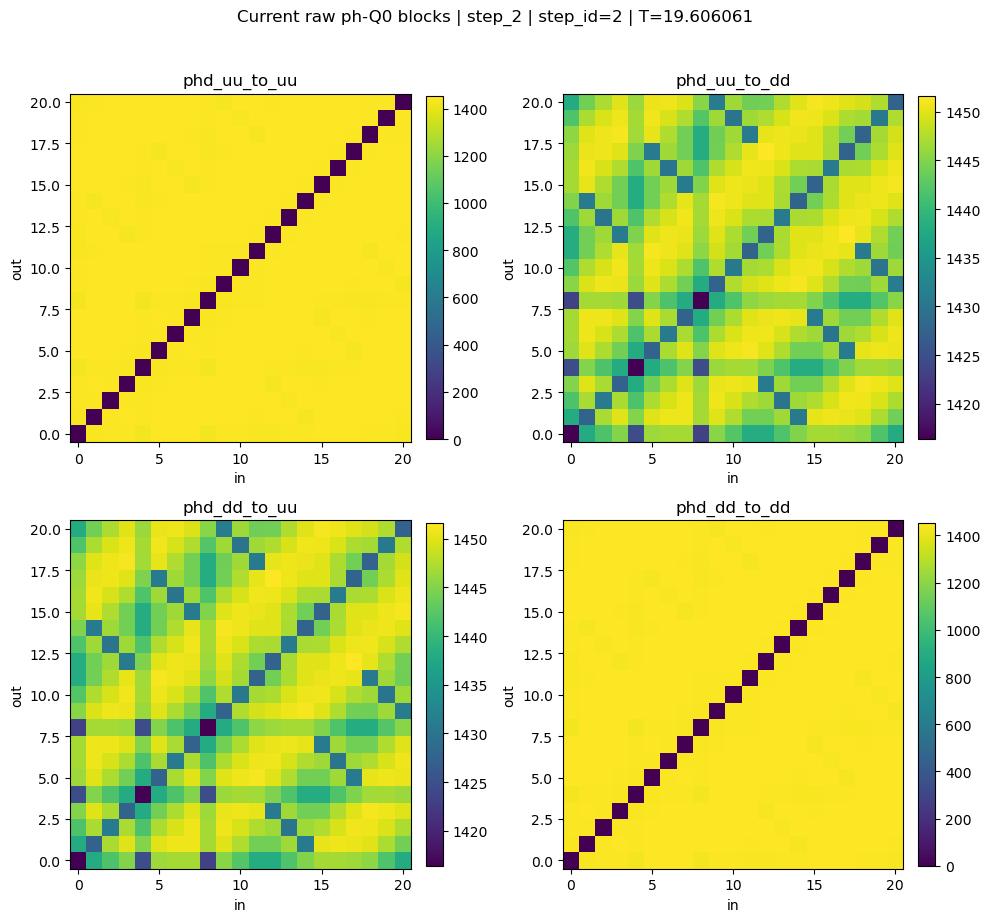


===== RHS contributions at the SAME snapshot =====
RHS part = pp
phd_uu_to_uu   | max=2723.03 | diag_mean=7.85687e-20 | off_mean=2702.53 | off_std=19.2546
phd_uu_to_dd   | max=2723.03 | diag_mean=2631.06 | off_mean=2701.84 | off_std=19.9678
phd_dd_to_uu   | max=2723.03 | diag_mean=2631.06 | off_mean=2701.84 | off_std=19.9678
phd_dd_to_dd   | max=2723.03 | diag_mean=9.11512e-20 | off_mean=2702.53 | off_std=19.2546


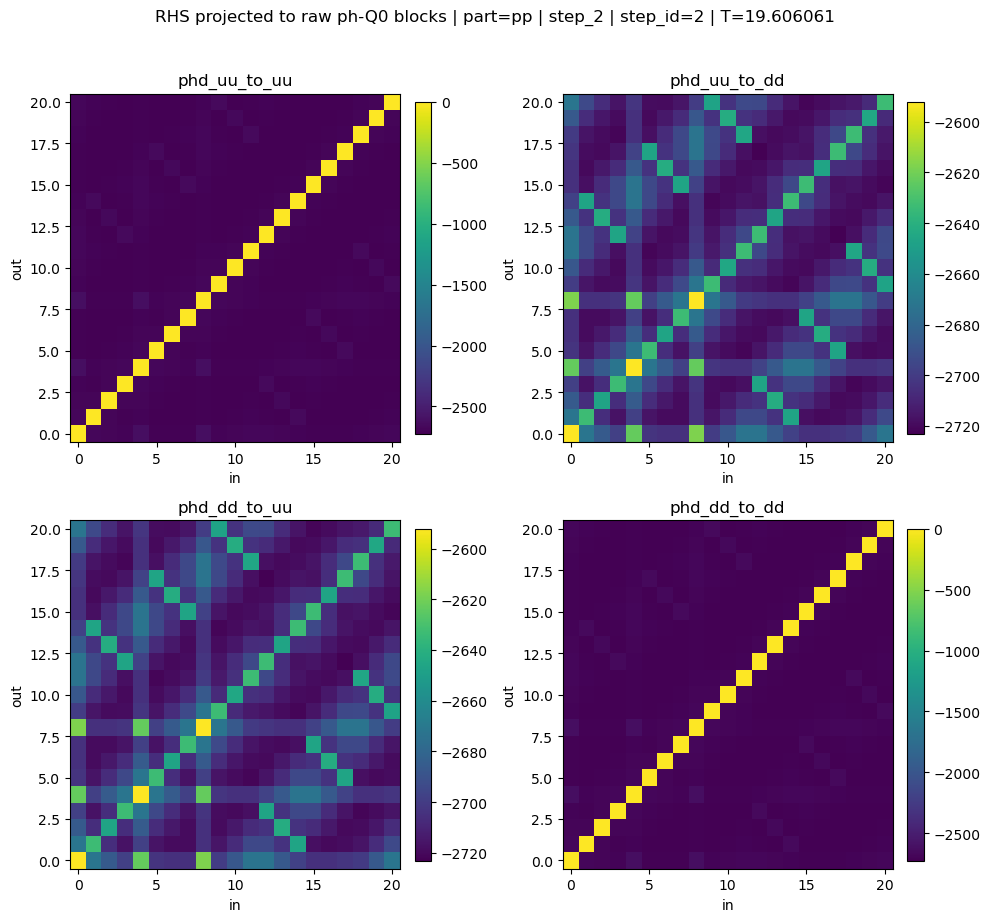

RHS part = phd
phd_uu_to_uu   | max=110868 | diag_mean=110715 | off_mean=108010 | off_std=197.676
phd_uu_to_dd   | max=108226 | diag_mean=108084 | off_mean=108011 | off_std=198.256
phd_dd_to_uu   | max=108226 | diag_mean=108084 | off_mean=108011 | off_std=198.256
phd_dd_to_dd   | max=110868 | diag_mean=110715 | off_mean=108010 | off_std=197.676


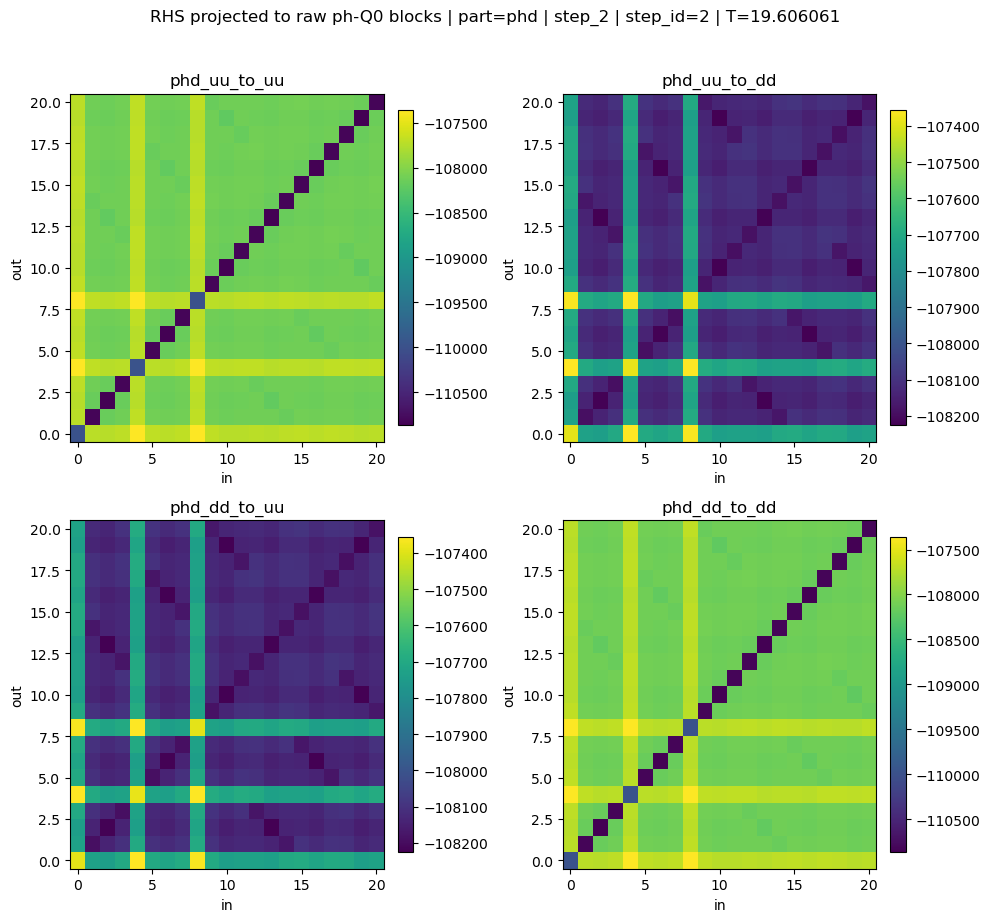

RHS part = phc
phd_uu_to_uu   | max=110868 | diag_mean=110715 | off_mean=1426.95 | off_std=300.567
phd_uu_to_dd   | max=2647.05 | diag_mean=2630.98 | off_mean=1426.37 | off_std=298.624
phd_dd_to_uu   | max=2647.05 | diag_mean=2630.98 | off_mean=1426.37 | off_std=298.624
phd_dd_to_dd   | max=110868 | diag_mean=110715 | off_mean=1426.95 | off_std=300.567


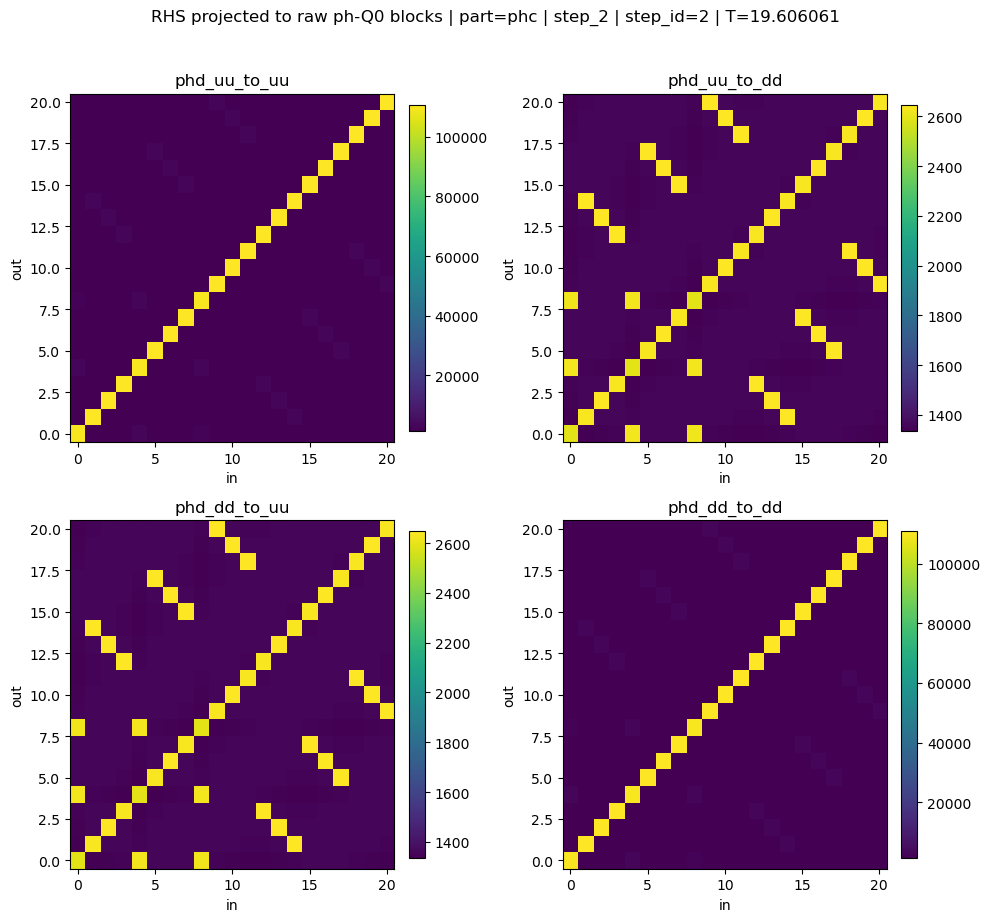

RHS part = total
phd_uu_to_uu   | max=109509 | diag_mean=0 | off_mean=109286 | off_std=380.219
phd_uu_to_dd   | max=109509 | diag_mean=108084 | off_mean=109286 | off_std=378.9
phd_dd_to_uu   | max=109509 | diag_mean=108084 | off_mean=109286 | off_std=378.9
phd_dd_to_dd   | max=109509 | diag_mean=0 | off_mean=109286 | off_std=380.219


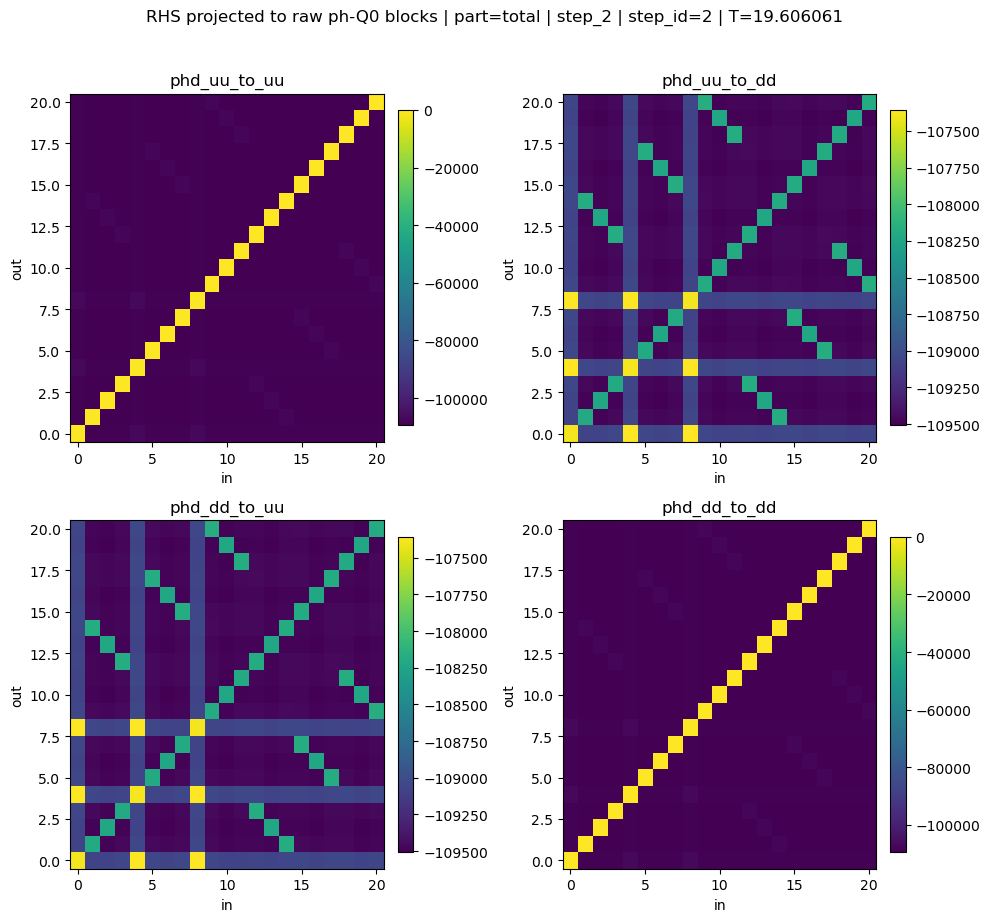

In [59]:
# Pick which representative snapshot to inspect
inspect_id = min(2, len(snapshots_V3_long) - 1)
snap = snapshots_V3_long[inspect_id]

print(f"Inspect RHS contributions at snapshot: {snap['label']} | step_id={snap['step_id']} | T={snap['T']:.6f}\n")

print("===== Current vertex kernel at the SAME snapshot =====")
print_raw_summary(
    snap["raw_now"],
    title="Current raw Q=0 blocks"
)
plot_raw_2x2(
    snap["raw_now"],
    suptitle=f"Current raw ph-Q0 blocks | {snap['label']} | step_id={snap['step_id']} | T={snap['T']:.6f}"
)

print("\n===== RHS contributions at the SAME snapshot =====")
for part in ["pp", "phd", "phc", "total"]:
    print_raw_summary(
        snap["rhs_raw"][part],
        title=f"RHS part = {part}"
    )
    plot_raw_2x2(
        snap["rhs_raw"][part],
        suptitle=f"RHS projected to raw ph-Q0 blocks | part={part} | {snap['label']} | step_id={snap['step_id']} | T={snap['T']:.6f}"
    )

In [63]:
import numpy as np
import pandas as pd

from frg_kernel import normalize_spin
from channels import FullVertexChannelBuilder


def _canon_block(block):
    return tuple(normalize_spin(s) for s in block)


def _allowed_set_from_solver(solver):
    return {_canon_block(b) for b in solver.spin_blocks}


def inspect_internal_spin_support(
    solver,
    ext_block,
    *,
    channel="phd",
):
    """
    Return which internal spin pairs (sa,sb) are allowed for a given
    external full-vertex spin block (s1,s2,s3,s4), separately for the
    two explicit permutation terms in the loop.

    channel = 'phd' or 'phc'
    """
    s1, s2, s3, s4 = _canon_block(ext_block)
    allowed = _allowed_set_from_solver(solver)

    rows = []
    for sa in ("up", "dn"):
        for sb in ("up", "dn"):
            if channel == "phd":
                blk1_left  = (s1, sa, s3, sb)
                blk1_right = (sb, s2, sa, s4)
                blk2_left  = (s1, sb, s3, sa)
                blk2_right = (sa, s2, sb, s4)
            elif channel == "phc":
                blk1_left  = (s1, sa, s4, sb)
                blk1_right = (sb, s2, sa, s3)
                blk2_left  = (s1, sb, s4, sa)
                blk2_right = (sa, s2, sb, s3)
            else:
                raise ValueError("channel must be 'phd' or 'phc'")

            keep1 = (blk1_left in allowed) and (blk1_right in allowed)
            keep2 = (blk2_left in allowed) and (blk2_right in allowed)

            rows.append({
                "channel": channel,
                "external_block": (s1, s2, s3, s4),
                "sa": sa,
                "sb": sb,
                "keep1": keep1,
                "keep2": keep2,
                "blk1_left": blk1_left,
                "blk1_right": blk1_right,
                "blk2_left": blk2_left,
                "blk2_right": blk2_right,
            })

    df = pd.DataFrame(rows)
    return df


def inspect_raw_phQ0_block_spin_support(
    solver,
    raw_name,
):
    """
    Translate a raw ph-Q0 block name into the corresponding external full-vertex
    spin block, then inspect phd/phc internal-spin support.

    Supported raw names:
      'phd_uu_to_uu', 'phd_uu_to_dd', 'phd_dd_to_uu', 'phd_dd_to_dd'
    """
    mapping = {
        "phd_uu_to_uu": ("up", "up", "up", "up"),
        "phd_uu_to_dd": ("up", "dn", "up", "dn"),
        "phd_dd_to_uu": ("dn", "up", "dn", "up"),
        "phd_dd_to_dd": ("dn", "dn", "dn", "dn"),
    }
    if raw_name not in mapping:
        raise ValueError(f"Unsupported raw_name={raw_name}")

    ext_block = mapping[raw_name]
    df_phd = inspect_internal_spin_support(solver, ext_block, channel="phd")
    df_phc = inspect_internal_spin_support(solver, ext_block, channel="phc")

    return ext_block, df_phd, df_phc

In [65]:
# ---- choose your solver object here ----
# solver = fm_result["solver"]
# solver = sBO["solver"]
# solver = YOUR_SOLVER
solver = solver  # if you already named it solver

for raw_name in [
    "phd_uu_to_uu",
    "phd_uu_to_dd",
    "phd_dd_to_uu",
    "phd_dd_to_dd",
]:
    ext_block, df_phd, df_phc = inspect_raw_phQ0_block_spin_support(solver, raw_name)

    print("\n" + "=" * 90)
    print(f"raw ph-Q0 block: {raw_name}")
    print(f"corresponding external full-vertex spin block: {ext_block}")

    print("\n[phd] internal-spin support")
    display(df_phd[["sa", "sb", "keep1", "keep2", "blk1_left", "blk1_right", "blk2_left", "blk2_right"]])

    print("\n[phc] internal-spin support")
    display(df_phc[["sa", "sb", "keep1", "keep2", "blk1_left", "blk1_right", "blk2_left", "blk2_right"]])

    keep_phd = df_phd.loc[df_phd["keep1"] | df_phd["keep2"], ["sa", "sb"]].values.tolist()
    keep_phc = df_phc.loc[df_phc["keep1"] | df_phc["keep2"], ["sa", "sb"]].values.tolist()

    print(f"\nallowed internal pairs in phd: {keep_phd}")
    print(f"allowed internal pairs in phc: {keep_phc}")


raw ph-Q0 block: phd_uu_to_uu
corresponding external full-vertex spin block: ('up', 'up', 'up', 'up')

[phd] internal-spin support


,sa,sb,keep1,keep2,blk1_left,blk1_right,blk2_left,blk2_right
0,up,up,True,True,"(up, up, up, up)","(up, up, up, up)","(up, up, up, up)","(up, up, up, up)"
1,up,dn,False,False,"(up, up, up, dn)","(dn, up, up, up)","(up, dn, up, up)","(up, up, dn, up)"
2,dn,up,False,False,"(up, dn, up, up)","(up, up, dn, up)","(up, up, up, dn)","(dn, up, up, up)"
3,dn,dn,True,True,"(up, dn, up, dn)","(dn, up, dn, up)","(up, dn, up, dn)","(dn, up, dn, up)"



[phc] internal-spin support


,sa,sb,keep1,keep2,blk1_left,blk1_right,blk2_left,blk2_right
0,up,up,True,True,"(up, up, up, up)","(up, up, up, up)","(up, up, up, up)","(up, up, up, up)"
1,up,dn,False,False,"(up, up, up, dn)","(dn, up, up, up)","(up, dn, up, up)","(up, up, dn, up)"
2,dn,up,False,False,"(up, dn, up, up)","(up, up, dn, up)","(up, up, up, dn)","(dn, up, up, up)"
3,dn,dn,True,True,"(up, dn, up, dn)","(dn, up, dn, up)","(up, dn, up, dn)","(dn, up, dn, up)"



allowed internal pairs in phd: [['up', 'up'], ['dn', 'dn']]
allowed internal pairs in phc: [['up', 'up'], ['dn', 'dn']]

raw ph-Q0 block: phd_uu_to_dd
corresponding external full-vertex spin block: ('up', 'dn', 'up', 'dn')

[phd] internal-spin support


...


allowed internal pairs in phd: [['up', 'up'], ['dn', 'dn']]
allowed internal pairs in phc: [['up', 'dn'], ['dn', 'up']]

raw ph-Q0 block: phd_dd_to_dd
corresponding external full-vertex spin block: ('dn', 'dn', 'dn', 'dn')

[phd] internal-spin support


,sa,sb,keep1,keep2,blk1_left,blk1_right,blk2_left,blk2_right
0,up,up,True,True,"(dn, up, dn, up)","(up, dn, up, dn)","(dn, up, dn, up)","(up, dn, up, dn)"
1,up,dn,False,False,"(dn, up, dn, dn)","(dn, dn, up, dn)","(dn, dn, dn, up)","(up, dn, dn, dn)"
2,dn,up,False,False,"(dn, dn, dn, up)","(up, dn, dn, dn)","(dn, up, dn, dn)","(dn, dn, up, dn)"
3,dn,dn,True,True,"(dn, dn, dn, dn)","(dn, dn, dn, dn)","(dn, dn, dn, dn)","(dn, dn, dn, dn)"



[phc] internal-spin support


,sa,sb,keep1,keep2,blk1_left,blk1_right,blk2_left,blk2_right
0,up,up,True,True,"(dn, up, dn, up)","(up, dn, up, dn)","(dn, up, dn, up)","(up, dn, up, dn)"
1,up,dn,False,False,"(dn, up, dn, dn)","(dn, dn, up, dn)","(dn, dn, dn, up)","(up, dn, dn, dn)"
2,dn,up,False,False,"(dn, dn, dn, up)","(up, dn, dn, dn)","(dn, up, dn, dn)","(dn, dn, up, dn)"
3,dn,dn,True,True,"(dn, dn, dn, dn)","(dn, dn, dn, dn)","(dn, dn, dn, dn)","(dn, dn, dn, dn)"



allowed internal pairs in phd: [['up', 'up'], ['dn', 'dn']]
allowed internal pairs in phc: [['up', 'up'], ['dn', 'dn']]
